In [1]:
# ============================================================
# REAL-TIME MIGRATION PRESSURE INDEX (RMPI) - DATA PIPELINE
# ============================================================
# This notebook collects and processes climate data for subnational regions.
# Sources tested: NASA POWER API, World Bank (fallback), CHIRPS (main source).
# ============================================================

import os
import time
import requests
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# 1. PATH SETTINGS
# ------------------------------------------------------------
base_dir = "/Users/ayodele/Python Projects/RMPI Project"
regions_path = os.path.join(base_dir, "gadm_410-levels.gpkg")
climate_path = os.path.join(base_dir, "data/processed/climate_full.csv")

# ------------------------------------------------------------
# 2. LOAD REGIONS (LEVEL 1 ADMIN UNITS)
# ------------------------------------------------------------
# Inspect layers: ['ADM_0', 'ADM_1', 'ADM_2', 'ADM_3', 'ADM_4', 'ADM_5']
gdf_regions = gpd.read_file(regions_path, layer="ADM_1")

print("Available columns:", gdf_regions.columns)

# Reproject -> compute centroids safely -> reproject back
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_regions["centroid"] = gdf_regions.geometry.centroid
gdf_regions = gdf_regions.to_crs(epsg=4326)

# Extract lat/lon
gdf_regions["lat"] = gdf_regions.centroid.y
gdf_regions["lon"] = gdf_regions.centroid.x

# ------------------------------------------------------------
# 3. NASA POWER - FETCH CLIMATE FOR A SINGLE POINT
# ------------------------------------------------------------
def fetch_climate_point(lat, lon, region_id, start="201501", end="202212", retries=3):
    """
    Fetch monthly precipitation (PRECTOTCORR) and temperature (T2M)
    from NASA POWER API for a single region.
    """
    url = (
        "https://power.larc.nasa.gov/api/temporal/monthly/point"
        f"?parameters=PRECTOTCORR,T2M"
        f"&community=AG"
        f"&longitude={lon}&latitude={lat}"
        f"&start={start}&end={end}"
        f"&format=JSON"
    )
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=30)
            if r.status_code != 200:
                time.sleep(2)
                continue
            data = r.json().get("properties", {}).get("parameter", {})
            if not data:
                return None

            precip = data.get("PRECTOTCORR", {})
            temp = data.get("T2M", {})

            df = pd.DataFrame({
                "time": list(precip.keys()),
                "precip_mm": list(precip.values()),
                "temperature_C": list(temp.values())
            })
            df["region_id"] = region_id
            return df
        except Exception as e:
            print(f"Error for {region_id}: {e}")
            time.sleep(2)
    return None

# ------------------------------------------------------------
# 4. LOOP OVER ALL REGIONS (NASA POWER)
# ------------------------------------------------------------
climate_list = []
for i, row in tqdm(gdf_regions.iterrows(), total=len(gdf_regions)):
    region_id = row["GID_1"]    # unique region code
    lat, lon = row["lat"], row["lon"]

    df_reg = fetch_climate_point(lat, lon, region_id)
    if df_reg is not None:
        climate_list.append(df_reg)

# Combine into single DataFrame
if climate_list:
    df_climate = pd.concat(climate_list, ignore_index=True)
    df_climate.to_csv(climate_path, index=False)
    print(f"Climate data saved: {climate_path}")
    print(df_climate.head())
else:
    print("No climate data fetched.")

# ------------------------------------------------------------
# 5. RETRY LOOP FOR MISSING REGIONS
# ------------------------------------------------------------
# Example template for retrying failed regions
missing_regions = ["FRA.4_1", "PRI.64_1", "FIN.2_1"]  # sample IDs
retry_data = []

for region_id in missing_regions:
    row = gdf_regions[gdf_regions["GID_1"] == region_id]
    if row.empty:
        continue
    lat, lon = row.iloc[0]["lat"], row.iloc[0]["lon"]
    df_reg = fetch_climate_point(lat, lon, region_id)
    if df_reg is not None:
        retry_data.append(df_reg)

if retry_data:
    df_retry = pd.concat(retry_data, ignore_index=True)
    df_retry.to_csv(climate_path, mode="a", header=False, index=False)

# ------------------------------------------------------------
# 6. WORLD BANK (FALLBACK OPTION)
# ------------------------------------------------------------
import wbdata
import datetime

# Define indicators (annual only, less detailed than NASA/CHIRPS)
indicators = {
    "AG.LND.PRCP.MM": "precip_mm",        # Average annual precipitation (mm)
    "EN.CLIM.TEMP.MA": "temperature_C"    # Mean annual temperature (Celsius)
}

# Fetch World Bank data (country-level, not subnational!)
start_date = datetime.datetime(1981, 1, 1)
end_date = datetime.datetime(2022, 12, 31)

df_wb = wbdata.get_dataframe(indicators, date=(start_date, end_date))
df_wb = df_wb.reset_index().rename(columns={"country": "country_name", "date": "year"})

print("World Bank climate sample:")
print(df_wb.head())

Available columns: Index(['GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')


/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_33900/1476896643.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lat"] = gdf_regions.centroid.y
/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_33900/1476896643.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lon"] = gdf_regions.centroid.x
  1%|▎                                      | 31/3662 [04:01<7:52:01,  7.80s/it]


KeyboardInterrupt: 

In [119]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.8 MB/s eta 0:00:00


In [121]:
!pip install h5netcdf

In [124]:
!pip install netCDF4 h5netcdf --quiet

In [128]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [129]:
!{sys.executable} -m pip install netCDF4 h5netcdf

In [131]:
import sys
!{sys.executable} -m pip install netCDF4 h5netcdf

In [133]:
import importlib.util

print(importlib.util.find_spec("netCDF4"))

ModuleSpec(name='netCDF4', loader=<_frozen_importlib_external.SourceFileLoader object at 0x45f3f5520>, origin='/opt/anaconda3/lib/python3.12/site-packages/netCDF4/__init__.py', submodule_search_locations=['/opt/anaconda3/lib/python3.12/site-packages/netCDF4'])


In [134]:
import sys
!{sys.executable} -m pip install netCDF4 h5netcdf

In [2]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 38.0 MB/s eta 0:00:001m39.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


xarray.Dataset {
dimensions:
	time = 536 ;
	latitude = 2000 ;
	longitude = 7200 ;

variables:
	float32 precip(time, latitude, longitude) ;
		precip:units = mm/month ;
		precip:standard_name = convective precipitation rate ;
		precip:long_name = Climate Hazards group InfraRed Precipitation with Stations ;
		precip:time_step = month ;
		precip:geostatial_lat_min = -50.0 ;
		precip:geostatial_lat_max = 50.0 ;
		precip:geostatial_lon_min = -180.0 ;
		precip:geostatial_lon_max = 180.0 ;
	float32 latitude(latitude) ;
		latitude:units = degrees_north ;
		latitude:standard_name = latitude ;
		latitude:long_name = latitude ;
		latitude:axis = Y ;
	float32 longitude(longitude) ;
		longitude:units = degrees_east ;
		longitude:standard_name = longitude ;
		longitude:long_name = longitude ;
		longitude:axis = X ;
	datetime64[ns] time(time) ;
		time:standard_name = time ;
		time:axis = T ;

// global attributes:
	:Conventions = CF-1.6 ;
	:title = CHIRPS Version 2.0 ;
	:history = created by Climate H

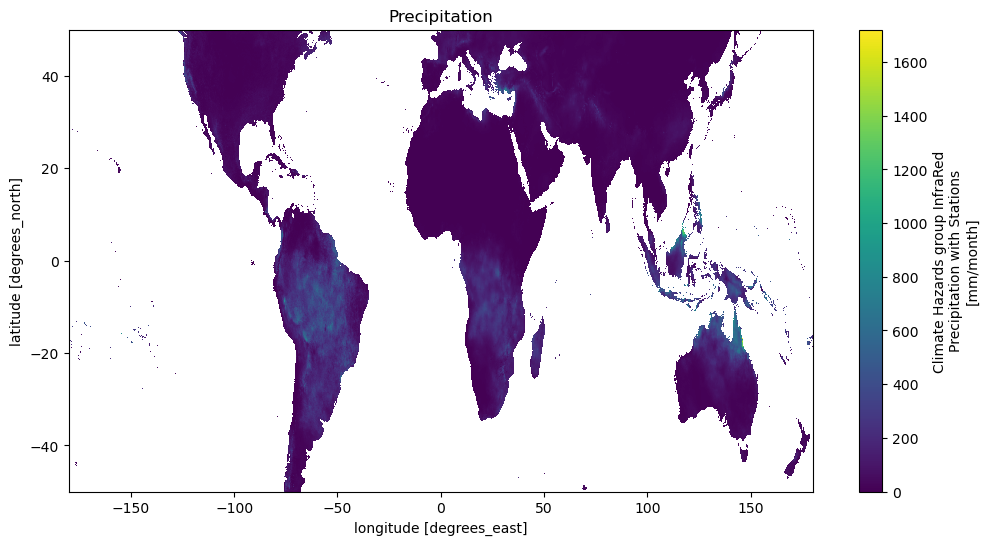

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Load the NetCDF file
ds = xr.open_dataset('/Users/ayodele/Python Projects/RMPI Project/data/raw/chirps/chirps-v2.0.monthly.nc')

# Basic information about the dataset
print(ds.info())

# Basic plot
plt.figure(figsize=(12, 6))
ds.precip.isel(time=0).plot()
plt.title('Precipitation')
plt.show()

In [6]:
import xarray as xr
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
from affine import Affine
import tqdm

# === Paths ===
chirps_path = "/Users/ayodele/Python Projects/RMPI Project/data/raw/chirps/chirps-v2.0.monthly.nc"
gadm_path   = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"
output_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/climate_regional.csv"

# === Load CHIRPS ===
ds = xr.open_dataset(chirps_path)
precip = ds["precip"]  # [time, latitude, longitude]

print("CHIRPS dimensions:", precip.shape)
print("Time range:", str(precip.time.values[0]), "to", str(precip.time.values[-1]))

# === Load GADM regions (Level 1) ===
gdf = gpd.read_file(gadm_path, layer="ADM_1")
gdf = gdf.to_crs("EPSG:4326")

print("Regions loaded:", len(gdf))

# === Define affine transform for CHIRPS ===
res = 0.05  # grid resolution (degrees)
transform = Affine(res, 0, -180, 0, -res, 50)  # pixel origin: top-left corner

# === Prepare results ===
results = []

# Process only a subset first (for testing, e.g., 12 months)
subset_precip = precip.isel(time=slice(0, 12))

for t in tqdm.tqdm(range(len(subset_precip.time)), desc="Processing time steps"):
    arr = subset_precip.isel(time=t).values  # numpy array for that month
    
    date = pd.to_datetime(str(subset_precip.time.values[t]))
    year, month = date.year, date.month
    
    zs = zonal_stats(
        vectors=gdf["geometry"],
        raster=arr,
        affine=transform,
        stats=["mean"],
        nodata=-9999
    )
    
    for i, z in enumerate(zs):
        results.append({
            "region_id": gdf.iloc[i]["GID_1"],
            "country": gdf.iloc[i]["GID_0"],
            "region_name": gdf.iloc[i]["NAME_1"],
            "year": year,
            "month": month,
            "precip_mm": z["mean"]
        })

# === Convert to DataFrame ===
df_climate = pd.DataFrame(results)
print(df_climate.head())

CHIRPS dimensions: (536, 2000, 7200)
Time range: 1981-01-01T00:00:00.000000000 to 2025-08-01T00:00:00.000000000
Regions loaded: 3662


Processing time steps: 100%|████████████████████| 12/12 [10:53<00:00, 54.46s/it]

  region_id country region_name  year  month  precip_mm
0   AFG.1_1     AFG  Badakhshan  1981      1        NaN
1   AFG.2_1     AFG     Badghis  1981      1        NaN
2   AFG.3_1     AFG     Baghlan  1981      1        NaN
3   AFG.4_1     AFG       Balkh  1981      1        NaN
4   AFG.5_1     AFG      Bamyan  1981      1        NaN


In [8]:
import pandas as pd

clim = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/climate_agg.csv")

print(clim.head())
print(clim.columns)

   precip_mm  temperature_C    time region_id region_name country_name
0       0.60         -11.86  202001   AFG.1_1  Badakhshan  Afghanistan
1       0.40          -6.95  202002   AFG.1_1  Badakhshan  Afghanistan
2       0.79          -3.12  202003   AFG.1_1  Badakhshan  Afghanistan
3       1.19           1.20  202004   AFG.1_1  Badakhshan  Afghanistan
4       0.66           4.92  202005   AFG.1_1  Badakhshan  Afghanistan
Index(['precip_mm', 'temperature_C', 'time', 'region_id', 'region_name',
       'country_name'],
      dtype='object')


In [9]:
import pandas as pd

# Load the aggregated climate file
clim = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/climate_agg.csv")

# 1. Overall missingness
print("Overall missingness (%):")
print(clim.isna().mean() * 100)

# 2. Missingness by country
missing_by_country = (
    clim.groupby("country_name")["precip_mm"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)
print("\nMissingness by country (top 20):")
print(missing_by_country.head(20))

# 3. Missingness by year
clim["year"] = clim["time"].astype(str).str[:4].astype(int)
missing_by_year = (
    clim.groupby("year")["precip_mm"]
    .apply(lambda x: x.isna().mean() * 100)
)
print("\nMissingness by year:")
print(missing_by_year.head(20))

Overall missingness (%):
precip_mm        0.0
temperature_C    0.0
time             0.0
region_id        0.0
region_name      0.0
country_name     0.0
dtype: float64

Missingness by country (top 20):
country_name
Afghanistan    0.0
Name: precip_mm, dtype: float64

Missingness by year:
year
2020    0.0
2021    0.0
2022    0.0
Name: precip_mm, dtype: float64


In [11]:
# ===============================================
# RMPI master merge (robust to climate file name)
# ===============================================

import os
import pandas as pd

# ---------- paths ----------
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
climate_regional_path = os.path.join(base_dir, "climate_regional.csv")
climate_agg_path      = os.path.join(base_dir, "climate_agg.csv")
out_path              = os.path.join(base_dir, "master_rmpi_final.csv")

# ---------- small helpers ----------
def standardize_cols(df):
    """Lowercase all columns and strip spaces."""
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def ensure_year_month(df):
    """Ensure df has integer 'year' and 'month' columns."""
    if "year" in df.columns and "month" in df.columns:
        df["year"] = df["year"].astype(int)
        df["month"] = df["month"].astype(int)
        return df

    if "time" in df.columns:
        s = df["time"].astype(str).str.replace(".0", "", regex=False)
        df["year"] = s.str.slice(0, 4).astype(int)
        df["month"] = s.str.slice(4, 6).astype(int)
        return df

    if "year" in df.columns:
        df["year"] = df["year"].astype(int)
    else:
        df["year"] = -1
    if "month" not in df.columns:
        df["month"] = 1
    return df

def ensure_country_id(df):
    """Ensure a 'country_id' (ISO3) column exists."""
    if "country_id" in df.columns:
        return df
    if "country" in df.columns:
        df = df.rename(columns={"country": "country_id"})
        return df
    if "countryiso3code" in df.columns:
        df["country_id"] = df["countryiso3code"]
        return df
    return df

def keep_cols(df, cols):
    """Keep only columns that exist (ignore missing ones)."""
    return df[[c for c in cols if c in df.columns]]

# ---------- load climate ----------
if os.path.exists(climate_regional_path):
    climate = pd.read_csv(climate_regional_path)
    climate = standardize_cols(climate)
    climate = ensure_year_month(climate)
    climate = ensure_country_id(climate)
    for col in ["precip_mm", "temperature_c"]:
        if col not in climate.columns:
            climate[col] = None
else:
    climate = pd.read_csv(climate_agg_path)
    climate = standardize_cols(climate)
    climate = ensure_year_month(climate)
    if "country_id" not in climate.columns:
        climate["country_id"] = None
    if "precip_mm" not in climate.columns:
        climate["precip_mm"] = None
    if "temperature_c" not in climate.columns:
        climate["temperature_c"] = None

climate = keep_cols(
    climate,
    ["region_id", "region_name", "country_id", "country_name", "year", "month", "precip_mm", "temperature_c"]
)

# ---------- load other datasets ----------
def load_csv(name):
    path = os.path.join(base_dir, name)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    return standardize_cols(df)

food_insec   = load_csv("food_insecurity.csv")
conflict     = load_csv("conflict_agg.csv")
gdp          = load_csv("gdp_per_capita.csv")
remittances  = load_csv("remittances.csv")
political    = load_csv("political_stability.csv")
unemployment = load_csv("unemployment.csv")
socio        = load_csv("socioeconomic_factors.csv")
child_pop    = load_csv("child_population.csv")

# Normalize keys
for df in [food_insec, gdp, remittances, political, unemployment, child_pop, socio]:
    if df is None:
        continue
    df = ensure_country_id(df)
    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    if df is food_insec:   food_insec = df
    if df is gdp:          gdp = df
    if df is remittances:  remittances = df
    if df is political:    political = df
    if df is unemployment: unemployment = df
    if df is child_pop:    child_pop = df
    if df is socio:        socio = df

# Trim to essential columns
if food_insec is not None:
    food_insec = keep_cols(food_insec, ["country_id", "country_name", "year", "undernourished_percent"])
if gdp is not None:
    gdp = keep_cols(gdp, ["country_id", "year", "gdp_per_capita"])
if remittances is not None:
    remittances = keep_cols(remittances, ["country_id", "year", "remittances_percent_gdp"])
if political is not None:
    political = keep_cols(political, ["country_id", "year", "political_stability"])
if unemployment is not None:
    unemployment = keep_cols(unemployment, ["country_id", "year", "unemployment_percent"])
if child_pop is not None:
    if "pop_0_14_percent" in child_pop.columns:
        child_pop = keep_cols(child_pop, ["country_id", "year", "pop_0_14_percent"])
    else:
        child_pop = keep_cols(child_pop, ["country_id", "year"])
if socio is not None:
    socio = keep_cols(
        socio,
        ["country_id", "country_name", "unemployment_percent", "pop_0_14_percent", "gdp_per_capita", "political_stability", "remittances_percent_gdp"]
    )

# ---------- merge pipeline ----------
master = climate.copy()

# 1) conflict (regional)
if conflict is not None:
    conflict_min = keep_cols(conflict, ["region_id", "events", "fatalities"])
    master = master.merge(conflict_min, on="region_id", how="left")

# 2) country-year merges
def merge_country_year(left, right):
    if right is None or right.empty:
        return left
    if "country_id" in left.columns and "country_id" in right.columns and "year" in left.columns and "year" in right.columns:
        return left.merge(right, on=["country_id", "year"], how="left")
    if "country_name" in left.columns and "country_name" in right.columns and "year" in left.columns and "year" in right.columns:
        return left.merge(right, on=["country_name", "year"], how="left")
    if "country_id" in left.columns and "country_id" in right.columns:
        return left.merge(right, on="country_id", how="left")
    if "country_name" in left.columns and "country_name" in right.columns:
        return left.merge(right, on="country_name", how="left")
    return left

for table in [food_insec, gdp, remittances, political, unemployment, child_pop]:
    master = merge_country_year(master, table)

# 3) socio (static, country-level)
if socio is not None and not socio.empty:
    if "country_id" in master.columns and "country_id" in socio.columns:
        master = master.merge(socio, on="country_id", how="left", suffixes=("", "_socio"))
    elif "country_name" in master.columns and "country_name" in socio.columns:
        master = master.merge(socio, on="country_name", how="left", suffixes=("", "_socio"))

# ---------- final tidy ----------
master = master.loc[:, ~master.columns.duplicated()]

print("Master shape:", master.shape)
print("Master columns:", list(master.columns)[:30], " ...")
print(master.head(3))

na_pct = master.isna().mean().sort_values(ascending=False) * 100
print("\nMissingness (%), top 20:\n", na_pct.head(20))

master.to_csv(out_path, index=False)
print(f"\nSaved master dataset to: {out_path}")

Master shape: (195, 23)
Master columns: ['region_id', 'region_name', 'country_id', 'country_name_x', 'year', 'month', 'precip_mm', 'temperature_c', 'events', 'fatalities', 'country_name_y', 'undernourished_percent', 'gdp_per_capita', 'remittances_percent_gdp', 'political_stability', 'unemployment_percent', 'pop_0_14_percent', 'country_name', 'unemployment_percent_socio', 'pop_0_14_percent_socio', 'gdp_per_capita_socio', 'political_stability_socio', 'remittances_percent_gdp_socio']  ...
  region_id region_name country_id country_name_x  year  month  precip_mm  \
0   AFG.1_1  Badakhshan       None    Afghanistan  2020      1       0.60   
1   AFG.1_1  Badakhshan       None    Afghanistan  2020      2       0.40   
2   AFG.1_1  Badakhshan       None    Afghanistan  2020      3       0.79   

   temperature_c  events  fatalities  ... remittances_percent_gdp  \
0         -11.86     652        4887  ...                     NaN   
1          -6.95     652        4887  ...                     

In [13]:
import os
import pandas as pd

# ---------- paths ----------
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
master = pd.read_csv(base_dir + "master_rmpi_final.csv")

# ---------- prepare date ----------
# Ensure year and month are numeric
master["year"] = pd.to_numeric(master["year"], errors="coerce")
master["month"] = pd.to_numeric(master["month"], errors="coerce")

# Drop rows where month is invalid (not between 1 and 12)
invalid_months = master.loc[~master["month"].between(1, 12)]
if not invalid_months.empty:
    print("Dropping invalid months:\n", invalid_months[["year", "month", "region_id"]])
    master = master.loc[master["month"].between(1, 12)]

# Now safely create a datetime column
master["date"] = pd.to_datetime(
    master["year"].astype(int).astype(str) + "-" +
    master["month"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

# Sort for later lag creation
master = master.sort_values(["region_id", "date"]).reset_index(drop=True)

print(master[["region_id", "year", "month", "date"]].head(12))

Dropping invalid months:
      year  month region_id
12   2020     13   AFG.1_1
25   2021     13   AFG.1_1
38   2022     13   AFG.1_1
51   2020     13   AFG.2_1
64   2021     13   AFG.2_1
77   2022     13   AFG.2_1
90   2020     13   AFG.3_1
103  2021     13   AFG.3_1
116  2022     13   AFG.3_1
129  2020     13   AFG.4_1
142  2021     13   AFG.4_1
155  2022     13   AFG.4_1
168  2020     13   AFG.5_1
181  2021     13   AFG.5_1
194  2022     13   AFG.5_1
   region_id  year  month       date
0    AFG.1_1  2020      1 2020-01-01
1    AFG.1_1  2020      2 2020-02-01
2    AFG.1_1  2020      3 2020-03-01
3    AFG.1_1  2020      4 2020-04-01
4    AFG.1_1  2020      5 2020-05-01
5    AFG.1_1  2020      6 2020-06-01
6    AFG.1_1  2020      7 2020-07-01
7    AFG.1_1  2020      8 2020-08-01
8    AFG.1_1  2020      9 2020-09-01
9    AFG.1_1  2020     10 2020-10-01
10   AFG.1_1  2020     11 2020-11-01
11   AFG.1_1  2020     12 2020-12-01


In [14]:
# ===============================================
# Step 2: Feature Engineering - Lags & Rolling Means
# ===============================================

import pandas as pd

# Reload cleaned master (with fixed months and dates)
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
master = pd.read_csv(base_dir + "master_rmpi_final.csv")

# Ensure proper date column
master = master[master["month"].between(1, 12)].copy()
master["date"] = pd.to_datetime(master["year"].astype(str) + "-" + master["month"].astype(str) + "-01")
master = master.sort_values(["region_id", "date"]).reset_index(drop=True)

# Pick numeric predictors for lags
numeric_cols = [
    "precip_mm", "temperature_c", 
    "events", "fatalities", 
    "undernourished_percent", 
    "gdp_per_capita", "remittances_percent_gdp", 
    "political_stability", "unemployment_percent", "pop_0_14_percent"
]

# Drop any missing from the list (if column not in dataset)
numeric_cols = [c for c in numeric_cols if c in master.columns]

# Define lag and rolling windows
lags = [1, 3]      # 1-month lag, 3-month lag
rolls = [3, 6]     # 3-month rolling mean, 6-month rolling mean

# Apply within each region
master_lagged = master.copy()
for col in numeric_cols:
    for lag in lags:
        master_lagged[f"{col}_lag{lag}"] = master_lagged.groupby("region_id")[col].shift(lag)
    for r in rolls:
        master_lagged[f"{col}_roll{r}"] = master_lagged.groupby("region_id")[col].shift(1).rolling(r).mean().reset_index(level=0, drop=True)

# Diagnostics
print("Final shape:", master_lagged.shape)
print("Example columns:", [c for c in master_lagged.columns if "lag" in c or "roll" in c][:20])
print(master_lagged.head(12))

# Save for next step
out_path = base_dir + "master_rmpi_features.csv"
master_lagged.to_csv(out_path, index=False)
print(f"\nSaved lagged feature dataset to: {out_path}")

Final shape: (180, 64)
Example columns: ['precip_mm_lag1', 'precip_mm_lag3', 'precip_mm_roll3', 'precip_mm_roll6', 'temperature_c_lag1', 'temperature_c_lag3', 'temperature_c_roll3', 'temperature_c_roll6', 'events_lag1', 'events_lag3', 'events_roll3', 'events_roll6', 'fatalities_lag1', 'fatalities_lag3', 'fatalities_roll3', 'fatalities_roll6', 'undernourished_percent_lag1', 'undernourished_percent_lag3', 'undernourished_percent_roll3', 'undernourished_percent_roll6']
   region_id region_name  country_id country_name_x  year  month  precip_mm  \
0    AFG.1_1  Badakhshan         NaN    Afghanistan  2020      1       0.60   
1    AFG.1_1  Badakhshan         NaN    Afghanistan  2020      2       0.40   
2    AFG.1_1  Badakhshan         NaN    Afghanistan  2020      3       0.79   
3    AFG.1_1  Badakhshan         NaN    Afghanistan  2020      4       1.19   
4    AFG.1_1  Badakhshan         NaN    Afghanistan  2020      5       0.66   
5    AFG.1_1  Badakhshan         NaN    Afghanistan  20

In [16]:
# ===============================================
# Step 3: Construct Proxy Migration Pressure Index (MPI)
# ===============================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
features = pd.read_csv(base_dir + "master_rmpi_features.csv")

# ---------- Select drivers for MPI ----------
# We normalize variables so they are comparable and directionally consistent
drivers = {
    "food_insec": "undernourished_percent",   # higher -> more migration pressure
    "conflict": "fatalities",                 # higher -> more pressure
    "precip": "precip_mm",                    # too low rainfall -> more pressure
    "temp": "temperature_c",                  # extreme high temp -> more pressure
    "econ": "gdp_per_capita",                 # lower GDP -> more pressure
    "youth": "pop_0_14_percent"               # higher youth share -> more pressure
}

# Keep only columns that exist
drivers = {k:v for k,v in drivers.items() if v in features.columns}

# Subset
df_mpi = features.copy()

# Normalize each driver (0–1 scale) so they are comparable
scaler = MinMaxScaler()

for k, col in drivers.items():
    if col not in df_mpi.columns:
        continue
    vals = df_mpi[[col]].values.astype(float)

    # GDP per capita is inversed (low GDP = more migration pressure)
    if col == "gdp_per_capita":
        vals = -vals

    df_mpi[f"{col}_norm"] = scaler.fit_transform(vals)

# ---------- Construct composite index ----------
# Simple equal-weight average of available normalized drivers
norm_cols = [c for c in df_mpi.columns if c.endswith("_norm")]
df_mpi["migration_pressure_index"] = df_mpi[norm_cols].mean(axis=1)

# ---------- Save ----------
out_path = base_dir + "master_rmpi_with_target.csv"
df_mpi.to_csv(out_path, index=False)

print("Constructed Migration Pressure Index")
print("Drivers used:", list(drivers.values()))
print("Saved to:", out_path)
print(df_mpi[["region_id", "year", "month", "migration_pressure_index"]].head())

Constructed Migration Pressure Index
Drivers used: ['undernourished_percent', 'fatalities', 'precip_mm', 'temperature_c', 'gdp_per_capita', 'pop_0_14_percent']
Saved to: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_target.csv
  region_id  year  month  migration_pressure_index
0   AFG.1_1  2020      1                  0.098922
1   AFG.1_1  2020      2                  0.129969
2   AFG.1_1  2020      3                  0.171908
3   AFG.1_1  2020      4                  0.217919
4   AFG.1_1  2020      5                  0.229157


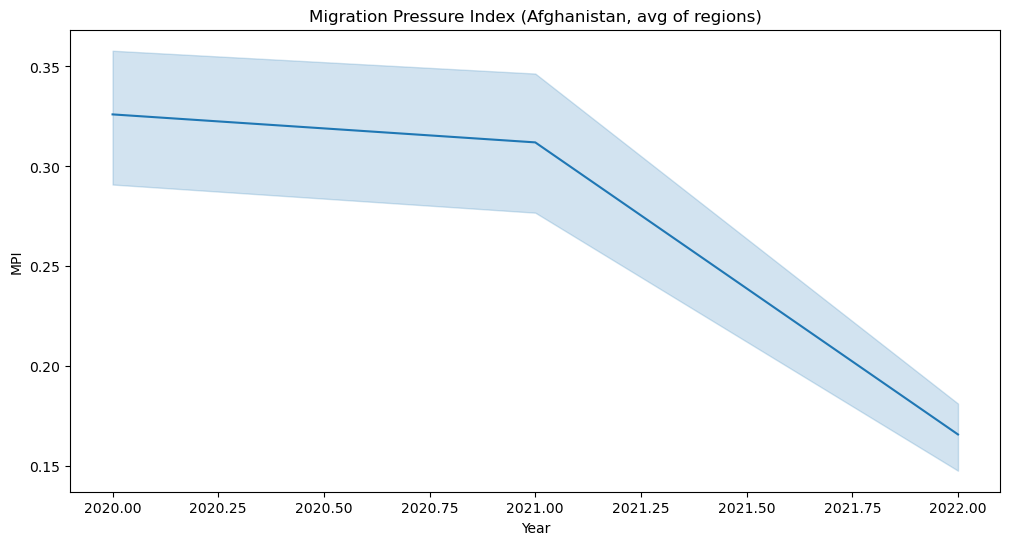


Top 5 regions by average MPI:
 region_id
AFG.4_1    0.475111
AFG.3_1    0.298641
AFG.2_1    0.264596
AFG.1_1    0.161865
AFG.5_1    0.139596
Name: migration_pressure_index, dtype: float64


<Figure size 1400x800 with 0 Axes>

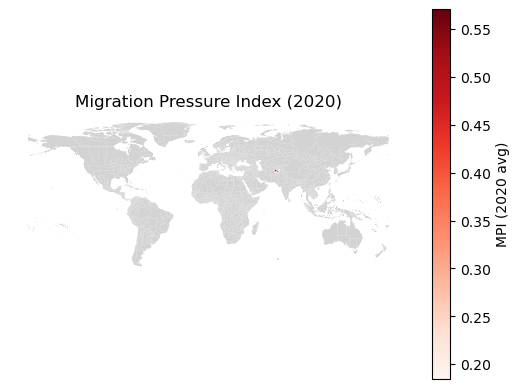

In [17]:
# ===============================================
# Step 2: Diagnostics & Visualization of MPI
# ===============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# ---------- paths ----------
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
mpi_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# ---------- load ----------
mpi = pd.read_csv(mpi_path)

# --- Time series plot for one country (Afghanistan example) ---
afg = mpi[mpi["region_id"].str.startswith("AFG")]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=afg.groupby(["year", "month"])["migration_pressure_index"].mean().reset_index(),
    x="year", y="migration_pressure_index"
)
plt.title("Migration Pressure Index (Afghanistan, avg of regions)")
plt.ylabel("MPI")
plt.xlabel("Year")
plt.show()

# --- Top 5 highest pressure regions (avg MPI over time) ---
top5 = (
    mpi.groupby("region_id")["migration_pressure_index"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("\nTop 5 regions by average MPI:\n", top5)

# --- Heatmap (choropleth) for one year (e.g., 2020) ---
# load GADM
gdf = gpd.read_file(gadm_path, layer="ADM_1")  # subnational
gdf = gdf.rename(columns={"GID_1": "region_id"})

# average MPI in 2020 by region
mpi_2020 = (
    mpi[mpi["year"] == 2020]
    .groupby("region_id")["migration_pressure_index"]
    .mean()
    .reset_index()
)

# merge with shapefile
gdf_mpi = gdf.merge(mpi_2020, on="region_id", how="left")

# plot
plt.figure(figsize=(14, 8))
gdf_mpi.plot(
    column="migration_pressure_index",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "MPI (2020 avg)"},
    missing_kwds={"color": "lightgrey"}
)
plt.title("Migration Pressure Index (2020)")
plt.axis("off")
plt.show()

Top 5 regions by average MPI:
 region_id
AFG.4_1    0.475111
AFG.3_1    0.298641
AFG.2_1    0.264596
AFG.1_1    0.161865
AFG.5_1    0.139596
Name: migration_pressure_index, dtype: float64


<Figure size 1400x800 with 0 Axes>

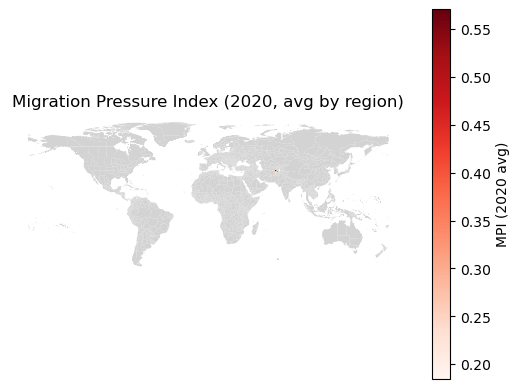

In [18]:
# ---------- Top 5 highest MPI regions ----------
top5 = (
    mpi.groupby("region_id")["migration_pressure_index"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 regions by average MPI:\n", top5)

# ---------- Choropleth map (2020 example) ----------
import geopandas as gpd
import matplotlib.pyplot as plt

# Load GADM shapefile (admin-1 regions)
gdf = gpd.read_file(gadm_path, layer="ADM_1")  # region-level
gdf = gdf.rename(columns={"GID_1": "region_id"})

# Aggregate MPI for 2020
mpi_2020 = (
    mpi[mpi["year"] == 2020]
    .groupby("region_id")["migration_pressure_index"]
    .mean()
    .reset_index()
)

# Merge
gdf_mpi = gdf.merge(mpi_2020, on="region_id", how="left")

# Plot
plt.figure(figsize=(14, 8))
gdf_mpi.plot(
    column="migration_pressure_index",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "MPI (2020 avg)"},
    missing_kwds={"color": "lightgrey"}
)
plt.title("Migration Pressure Index (2020, avg by region)")
plt.axis("off")
plt.show()

<Figure size 1200x800 with 0 Axes>

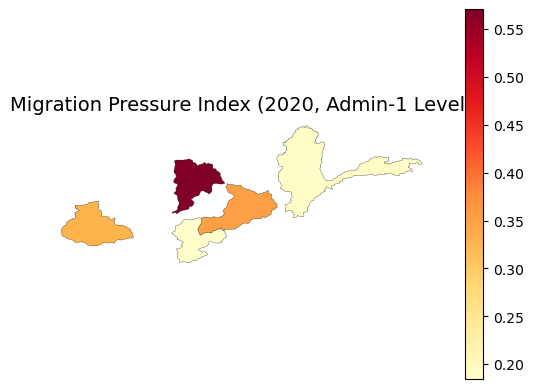

In [21]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Paths
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"
rmpi_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_target.csv"

# --- Load RMPI data ---
rmpi = pd.read_csv(rmpi_path)

# Aggregate to annual mean MPI for 2020 (example)
rmpi_2020 = (
    rmpi[rmpi["year"] == 2020]
    .groupby("region_id")["migration_pressure_index"]
    .mean()
    .reset_index()
)

# --- Load GADM admin-1 layer ---
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# Merge MPI into the GeoDataFrame
gdf = gdf.merge(rmpi_2020, left_on="GID_1", right_on="region_id", how="left")

# --- Plot ---
plt.figure(figsize=(12, 8))
gdf.plot(
    column="migration_pressure_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)
plt.title("Migration Pressure Index (2020, Admin-1 Level)", fontsize=14)
plt.axis("off")
plt.show()

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/"
data_path = os.path.join(base_dir, "data/processed/master_rmpi_with_target.csv")
gadm_path = os.path.join(base_dir, "gadm_410-levels.gpkg")
fig_dir = os.path.join(base_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# --- load data ---
rmpi = pd.read_csv(data_path)

# --- load GADM admin-1 layer ---
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# --- loop through years ---
for year in rmpi["year"].unique():
    rmpi_year = (
        rmpi[rmpi["year"] == year]
        .groupby("region_id")["migration_pressure_index"]
        .mean()
        .reset_index()
    )

    # merge with geodata
    gdf_yr = gdf.merge(rmpi_year, left_on="GID_1", right_on="region_id", how="left")

    # plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    gdf_yr.plot(
        column="migration_pressure_index",
        cmap="YlOrRd",
        linewidth=0.5,
        ax=ax,
        edgecolor="0.8",
        legend=True,
        legend_kwds={"label": f"MPI ({year}, avg by region)"}
    )
    ax.set_title(f"Migration Pressure Index ({year}, Admin-1 Level)", fontsize=14)
    ax.axis("off")

    # save
    out_path = os.path.join(fig_dir, f"mpi_map_{year}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()

print(f"Maps saved to: {fig_dir}")

Maps saved to: /Users/ayodele/Python Projects/RMPI Project/figures


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

# --- Load data ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data = pd.read_csv(base_dir + "master_rmpi_with_target.csv")

# Features and target
features = ["undernourished_percent", "fatalities", "precip_mm",
            "temperature_c", "gdp_per_capita", "pop_0_14_percent"]

X = data[features]
y = data["migration_pressure_index"]

# --- Handle missing values (impute with column mean) ---
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Fit baseline model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Coefficients
coeffs = pd.DataFrame({"feature": features, "coef": model.coef_})
print(coeffs)

R²: 0.6781828887095707
RMSE: 0.09223939135791066
                  feature          coef
0  undernourished_percent -1.462273e-07
1              fatalities  2.034961e-05
2               precip_mm  2.407859e-02
3           temperature_c  5.413567e-03
4          gdp_per_capita  1.151822e-05
5        pop_0_14_percent  7.873780e-08


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# --- Load data ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data = pd.read_csv(base_dir + "master_rmpi_with_target.csv")

# Features and target
features = ["undernourished_percent", "fatalities", "precip_mm",
            "temperature_c", "gdp_per_capita", "pop_0_14_percent"]

X = data[features]
y = data["migration_pressure_index"]

# --- Handle missing values (impute with column mean) ---
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# --- Random Forest model ---
rf = RandomForestRegressor(
    n_estimators=300,       # number of trees
    max_depth=None,        # let trees expand fully
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Random Forest R²:", r2_score(y_test, y_pred))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Feature importance
importances = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature importances:")
print(importances)

Random Forest R²: 0.49343641594414356
Random Forest RMSE: 0.11572544127454332

Feature importances:
                  feature  importance
1              fatalities    0.604919
3           temperature_c    0.221350
2               precip_mm    0.173731
0  undernourished_percent    0.000000
4          gdp_per_capita    0.000000
5        pop_0_14_percent    0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [27]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

# --- Load data ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data = pd.read_csv(base_dir + "master_rmpi_with_target.csv")

# Features and target
features = ["undernourished_percent", "fatalities", "precip_mm",
            "temperature_c", "gdp_per_capita", "pop_0_14_percent"]

X = data[features]
y = data["migration_pressure_index"]

# --- Handle missing values ---
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# --- XGBoost model ---
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)

# Evaluation
print("XGBoost R²:", r2_score(y_test, y_pred))
print("XGBoost RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Feature importance
importances = pd.DataFrame({
    "feature": features,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature importances (XGB):")
print(importances)

XGBoost R²: 0.37626776754479263
XGBoost RMSE: 0.12841358076673667

Feature importances (XGB):
                  feature  importance
1              fatalities    0.752569
3           temperature_c    0.142166
2               precip_mm    0.105265
0  undernourished_percent    0.000000
4          gdp_per_capita    0.000000
5        pop_0_14_percent    0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

# --- Load data ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data = pd.read_csv(base_dir + "master_rmpi_with_target.csv")

# Features and target
features = ["undernourished_percent", "fatalities", "precip_mm",
            "temperature_c", "gdp_per_capita", "pop_0_14_percent"]

X = data[features]
y = data["migration_pressure_index"]

# --- Handle missing values ---
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# --- Random Forest with hyperparameter tuning ---
rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,            # number of random combinations to try
    scoring="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

# --- Best model ---
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Best parameters:", search.best_params_)
print("R² (CV-tuned RF):", r2_score(y_test, y_pred))
print("RMSE (CV-tuned RF):", mean_squared_error(y_test, y_pred, squared=False))

# Feature importances
importances = pd.DataFrame({
    "feature": features,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importances (tuned RF):\n", importances)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
R² (CV-tuned RF): 0.6118021605886201
RMSE (CV-tuned RF): 0.10130675848946165

Feature importances (tuned RF):
                   feature  importance
1              fatalities    0.515161
3           temperature_c    0.311582
2               precip_mm    0.173257
0  undernourished_percent    0.000000
4          gdp_per_capita    0.000000
5        pop_0_14_percent    0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
from xgboost import XGBRegressor

# --- XGBoost with hyperparameter tuning ---
xgb = XGBRegressor(random_state=42, objective="reg:squarederror")

param_dist_xgb = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

# --- Best model ---
best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Best parameters (XGB):", search_xgb.best_params_)
print("R² (CV-tuned XGB):", r2_score(y_test, y_pred_xgb))
print("RMSE (CV-tuned XGB):", mean_squared_error(y_test, y_pred_xgb, squared=False))

# Feature importances
importances_xgb = pd.DataFrame({
    "feature": features,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importances (tuned XGB):\n", importances_xgb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters (XGB): {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
R² (CV-tuned XGB): 0.5589889615995323
RMSE (CV-tuned XGB): 0.10797832654268863

Feature importances (tuned XGB):
                   feature  importance
1              fatalities    0.725391
3           temperature_c    0.160074
2               precip_mm    0.114535
0  undernourished_percent    0.000000
4          gdp_per_capita    0.000000
5        pop_0_14_percent    0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [31]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions from each tuned model
y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

# Simple average ensemble
y_pred_ensemble = (y_pred_rf + y_pred_xgb) / 2

# Evaluation
print("Ensemble R²:", r2_score(y_test, y_pred_ensemble))
print("Ensemble RMSE:", mean_squared_error(y_test, y_pred_ensemble, squared=False))

# Compare individual vs ensemble
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Ensemble"],
    "R²": [r2_score(y_test, y_pred_rf),
           r2_score(y_test, y_pred_xgb),
           r2_score(y_test, y_pred_ensemble)],
    "RMSE": [mean_squared_error(y_test, y_pred_rf, squared=False),
             mean_squared_error(y_test, y_pred_xgb, squared=False),
             mean_squared_error(y_test, y_pred_ensemble, squared=False)]
})
print(results)

Ensemble R²: 0.5919609962395531
Ensemble RMSE: 0.1038634398266577
           Model        R²      RMSE
0  Random Forest  0.611802  0.101307
1        XGBoost  0.558989  0.107978
2       Ensemble  0.591961  0.103863


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

In [32]:
import joblib

# Save best RF
joblib.dump(best_rf, base_dir + "rmpi_rf_model.pkl")

# Save XGB if needed
joblib.dump(best_xgb, base_dir + "rmpi_xgb_model.pkl")

# Optionally save ensemble as function
def ensemble_predict(X):
    pred_rf = best_rf.predict(X)
    pred_xgb = best_xgb.predict(X)
    return (pred_rf + pred_xgb) / 2

# Save the ensemble wrapper
import pickle
with open(base_dir + "rmpi_ensemble.pkl", "wb") as f:
    pickle.dump(ensemble_predict, f)

print("Models saved to disk.")

Models saved to disk.


2025-09-26 21:33:45.525 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-09-26 21:33:45.555 
  command:

    streamlit run /opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-09-26 21:33:45.556 No runtime found, using MemoryCacheStorageManager
2025-09-26 21:33:46.923 Session state does not function when running a script without `streamlit run`


DeltaGenerator()

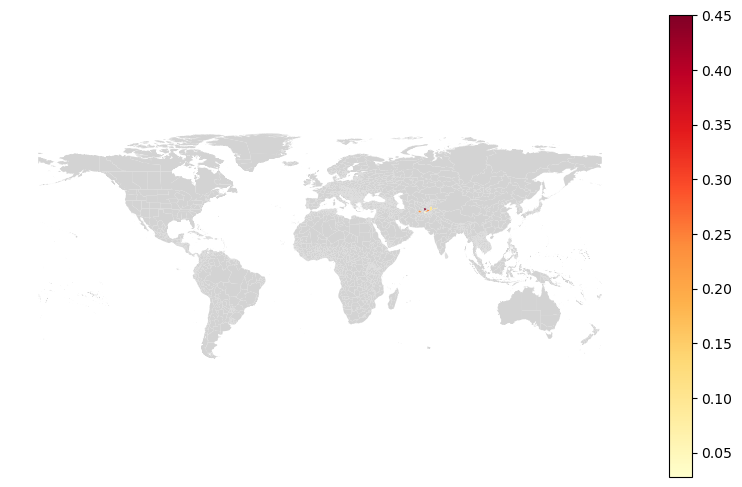

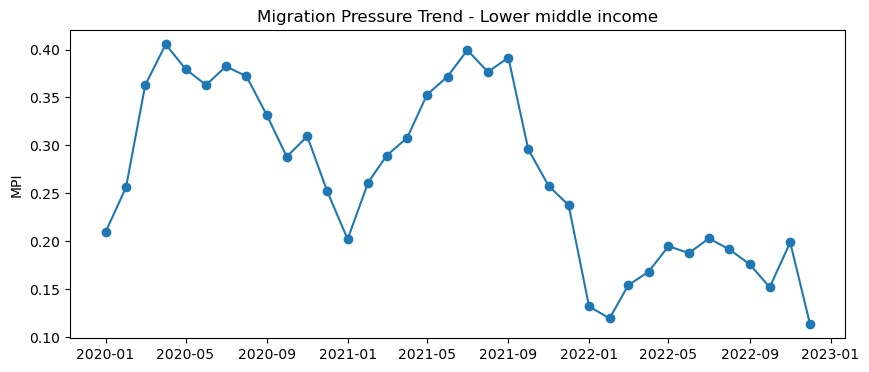

In [33]:
# streamlit_app.py

import streamlit as st
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# --- Load data ---
@st.cache_data
def load_data():
    df = pd.read_csv(data_path)
    gdf = gpd.read_file(gadm_path, layer="ADM_1")  # Admin-1 level
    return df, gdf

df, gdf = load_data()

# --- Sidebar filters ---
st.sidebar.header("Filters")
year = st.sidebar.selectbox("Year", sorted(df["year"].unique()))
month = st.sidebar.selectbox("Month", sorted(df["month"].unique()))
country = st.sidebar.selectbox("Country", sorted(df["country_name"].dropna().unique()))

# --- Filtered subset ---
subset = df[(df["year"] == year) & (df["month"] == month)]

# --- Merge with shapefile for map ---
gdf_map = gdf.merge(
    subset, left_on="GID_1", right_on="region_id", how="left"
)

# --- Choropleth of MPI ---
st.subheader(f"Migration Pressure Index (MPI) - {year}-{month:02d}")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
gdf_map.plot(
    column="migration_pressure_index",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)
ax.axis("off")
st.pyplot(fig)

# --- Time series for chosen country ---
st.subheader(f"MPI Trend for {country}")
country_df = df[df["country_name"] == country].groupby(["year", "month"])["migration_pressure_index"].mean().reset_index()
country_df["date"] = pd.to_datetime(country_df["year"].astype(str) + "-" + country_df["month"].astype(str) + "-01")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(country_df["date"], country_df["migration_pressure_index"], marker="o")
ax.set_ylabel("MPI")
ax.set_title(f"Migration Pressure Trend - {country}")
st.pyplot(fig)

In [3]:
import pandas as pd
import geopandas as gpd

# --- Paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# --- Load RMPI data ---
df = pd.read_csv(data_path)

# --- Load shapefile (Admin-1) ---
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# Print available columns so you know what exists
print("Columns in ADM_1 shapefile:")
print(gdf.columns.tolist())

# Try to standardize names: country and region
# Adjust depending on which columns are present
possible_country_cols = ["NAME_0", "COUNTRY", "CNTRY_NAME"]
possible_region_cols = ["NAME_1", "REGION", "ADM1_NAME"]

country_col = next((c for c in possible_country_cols if c in gdf.columns), None)
region_col = next((c for c in possible_region_cols if c in gdf.columns), None)

if not country_col or not region_col:
    raise ValueError("Could not find expected country/region name columns. Please check gdf.columns.")

# Keep only useful columns
gdf = gdf[["GID_1", country_col, region_col]]

# Merge shapefile with RMPI
df = df.merge(gdf, left_on="region_id", right_on="GID_1", how="left")

print("Merged data preview:")
print(df.head())

Columns in ADM_1 shapefile:
['GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Merged data preview:
  region_id region_name  country_id country_name_x  year  month  precip_mm  \
0   AFG.1_1  Badakhshan         NaN    Afghanistan  2020      1       0.60   
1   AFG.1_1  Badakhshan         NaN    Afghanistan  2020      2       0.40   
2   AFG.1_1  Badakhshan         NaN    Afghanistan  2020      3       0.79   
3   AFG.1_1  Badakhshan         NaN    Afghanistan  2020      4       1.19   
4   AFG.1_1  Badakhshan         NaN    Afghanistan  2020      5       0.66   

   temperature_c  events  fatalities  ... undernourished_percent_norm  \
0         -11.86     652        4887  ...                         NaN   
1          -6.95     652        4887  ...                         NaN   
2          -3.12     652        4887  ...                         NaN   
3           1.20     652        4887  ...                     

Plotting MPI Map for Afghanistan, 2020...


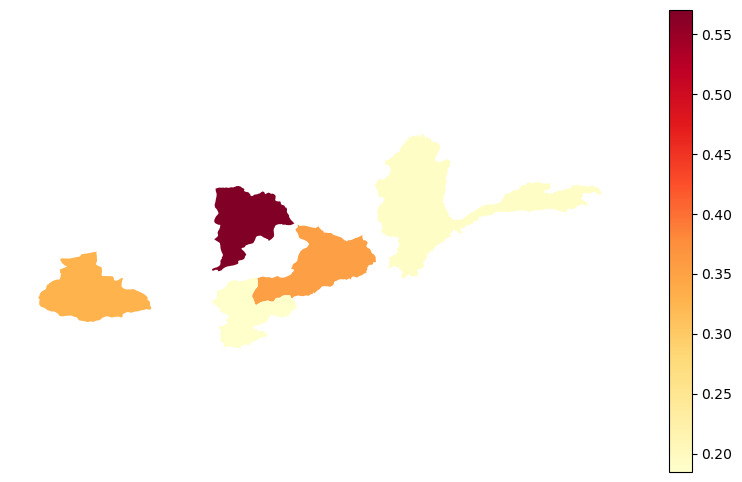

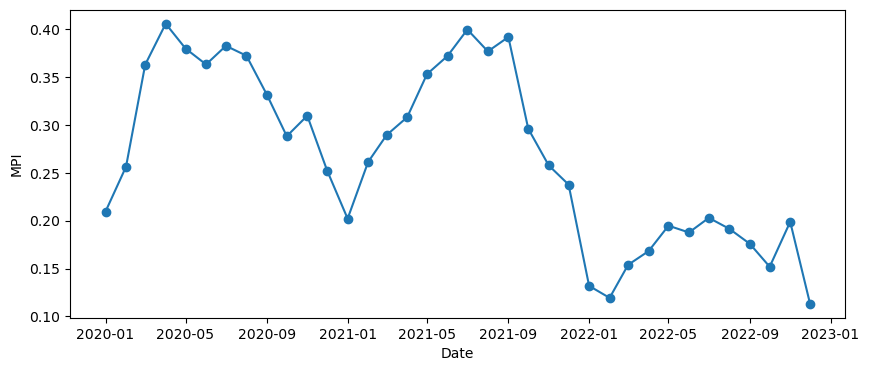

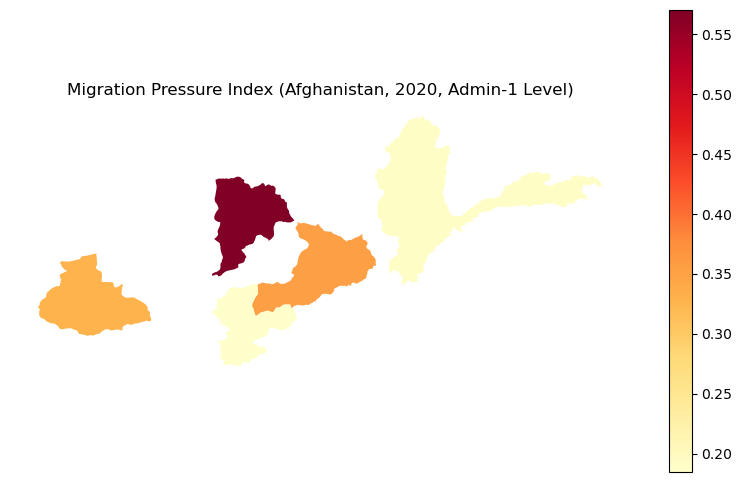

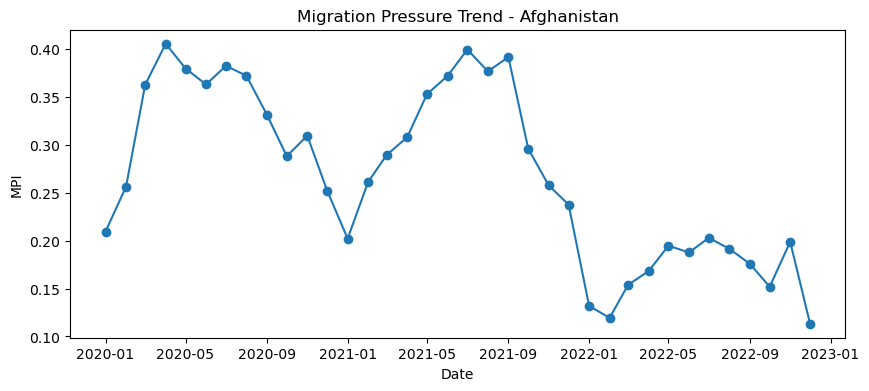

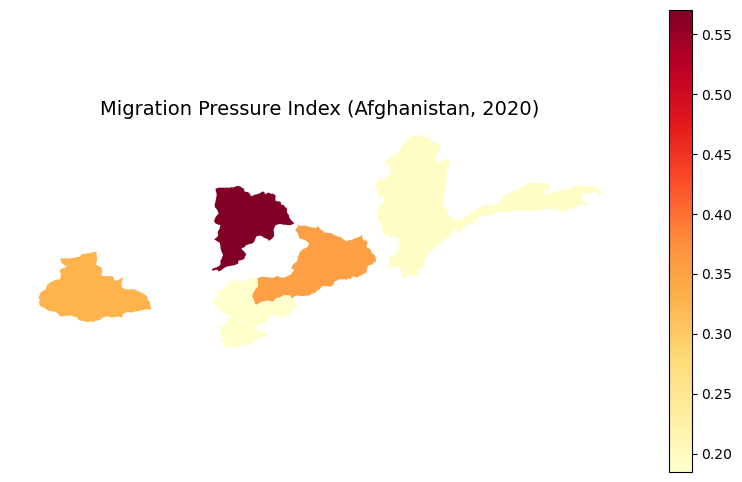

Plotting MPI Time Trend for Afghanistan...


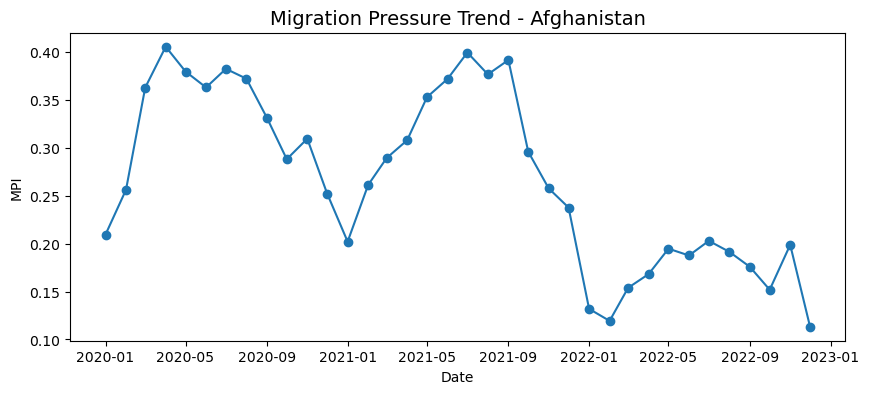

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure inline plotting
%matplotlib inline  

# --- Paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# --- Load Data ---
df = pd.read_csv(data_path)
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# Keep only useful columns
gdf = gdf[["GID_1", "COUNTRY", "NAME_1", "geometry"]]

# Merge MPI with shapefile info
df = df.merge(gdf, left_on="region_id", right_on="GID_1", how="left")

# Example country + year
country = "Afghanistan"
year = 2020

# --- MPI Map ---
print(f"Plotting MPI Map for {country}, {year}...")
rmpi_year = df[(df["COUNTRY"] == country) & (df["year"] == year)] \
    .groupby("region_id")["migration_pressure_index"].mean().reset_index()

gdf_merged = gdf.merge(rmpi_year, left_on="GID_1", right_on="region_id", how="left")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
gdf_merged.plot(column="migration_pressure_index", cmap="YlOrRd", legend=True, ax=ax)
ax.set_title(f"Migration Pressure Index ({country}, {year})", fontsize=14)
ax.axis("off")
plt.show()

# --- MPI Time Trend ---
print(f"Plotting MPI Time Trend for {country}...")
trend = df[df["COUNTRY"] == country].groupby(["year", "month"])["migration_pressure_index"].mean().reset_index()
trend["date"] = pd.to_datetime(trend["year"].astype(str) + "-" + trend["month"].astype(str) + "-01")

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(trend["date"], trend["migration_pressure_index"], marker="o")
ax2.set_title(f"Migration Pressure Trend - {country}", fontsize=14)
ax2.set_ylabel("MPI")
ax2.set_xlabel("Date")
plt.show()

In [2]:
import pandas as pd
import geopandas as gpd

# Paths
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# Load datasets
df = pd.read_csv(data_path)
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# Inspect unique values
print("Unique values in df['country_name']:", df["country_name"].unique()[:20])
print("\nUnique values in gdf['COUNTRY']:", gdf["COUNTRY"].unique()[:20])

Unique values in df['country_name']: ['Lower middle income']

Unique values in gdf['COUNTRY']: ['Afghanistan' 'Angola' 'Anguilla' 'Åland' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa'
 'French Southern Territories' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin'
 'Bonaire, Sint Eustatius and Saba' 'Burkina Faso']


In [3]:
import pandas as pd
import geopandas as gpd

# --- Paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# --- Load Data ---
df = pd.read_csv(data_path)
gdf = gpd.read_file(gadm_path, layer="ADM_1")

# Keep needed columns
gdf = gdf[["GID_1", "COUNTRY", "NAME_1"]].rename(
    columns={"GID_1": "region_id", "NAME_1": "region_name"}
)

# Merge RMPI data with real country names
df_corrected = df.merge(gdf, on="region_id", how="left")

# Aggregate to country level (average MPI by year)
country_mpi = (
    df_corrected.groupby(["COUNTRY", "year"])["migration_pressure_index"]
    .mean()
    .reset_index()
    .rename(columns={"COUNTRY": "country_name"})
)

print("Preview of corrected country-level MPI:")
print(country_mpi.head())

Preview of corrected country-level MPI:
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.326022
1  Afghanistan  2021                  0.312013
2  Afghanistan  2022                  0.165849


In [4]:
output_path = base_dir + "country_level_mpi.csv"
country_mpi.to_csv(output_path, index=False)
print(f"Saved corrected country-level MPI to: {output_path}")

Saved corrected country-level MPI to: /Users/ayodele/Python Projects/RMPI Project/data/processed/country_level_mpi.csv


In [3]:
import geopandas as gpd

# Path to your shapefile (same one you used in Streamlit)
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# Load countries only (ADM_0 = national boundaries)
gdf_countries = gpd.read_file(gadm_path, layer="ADM_0")

print(gdf_countries.head())

  GID_0      COUNTRY                                           geometry
0   ABW        Aruba  MULTIPOLYGON (((-69.9782 12.46986, -69.97847 1...
1   AFG  Afghanistan  MULTIPOLYGON (((63.61554 29.4697, 63.61425 29....
2   AGO       Angola  MULTIPOLYGON (((19.89892 -17.87674, 19.89082 -...
3   AIA     Anguilla  MULTIPOLYGON (((-63.02064 18.2075, -63.02587 1...
4   ALA        Åland  MULTIPOLYGON (((21.32306 59.74847, 21.32306 59...


In [2]:
import pandas as pd
import geopandas as gpd

# --- Paths ---
base_dir = "/Users/ayodele/Python Projects/RMPI Project/data/processed/"
data_path = base_dir + "master_rmpi_with_target.csv"
gadm_path = "/Users/ayodele/Python Projects/RMPI Project/gadm_410-levels.gpkg"

# --- Load RMPI dataset ---
df = pd.read_csv(data_path)

# --- Load shapefile (countries only) ---
gdf_countries = gpd.read_file(gadm_path, layer="ADM_0")

# Inspect names
print("Unique df countries:", df["country_name"].unique()[:20])
print("Unique shapefile countries:", gdf_countries["COUNTRY"].unique()[:20])

Unique df countries: ['Lower middle income']
Unique shapefile countries: ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Åland' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa'
 'Antarctica' 'French Southern Territories' 'Antigua and Barbuda'
 'Australia' 'Austria' 'Azerbaijan' 'Burundi' 'Belgium' 'Benin']


In [1]:
import pandas as pd

file = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_target.csv"
df = pd.read_csv(file)

print(df.columns)          # show all columns
print(df.head(10))         # preview first rows
print(df["country_name"].unique()[:30])  # unique country names

Index(['region_id', 'region_name', 'country_id', 'country_name_x', 'year',
       'month', 'precip_mm', 'temperature_c', 'events', 'fatalities',
       'country_name_y', 'undernourished_percent', 'gdp_per_capita',
       'remittances_percent_gdp', 'political_stability',
       'unemployment_percent', 'pop_0_14_percent', 'country_name',
       'unemployment_percent_socio', 'pop_0_14_percent_socio',
       'gdp_per_capita_socio', 'political_stability_socio',
       'remittances_percent_gdp_socio', 'date', 'precip_mm_lag1',
       'precip_mm_lag3', 'precip_mm_roll3', 'precip_mm_roll6',
       'temperature_c_lag1', 'temperature_c_lag3', 'temperature_c_roll3',
       'temperature_c_roll6', 'events_lag1', 'events_lag3', 'events_roll3',
       'events_roll6', 'fatalities_lag1', 'fatalities_lag3',
       'fatalities_roll3', 'fatalities_roll6', 'undernourished_percent_lag1',
       'undernourished_percent_lag3', 'undernourished_percent_roll3',
       'undernourished_percent_roll6', 'gdp_per_cap

In [2]:
import pandas as pd

# Path to your processed dataset
data_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_target.csv"

# Load dataset
df = pd.read_csv(data_path)

# Check year coverage
print("Year range in dataset:", df["year"].min(), "-", df["year"].max())
print("Unique years:", sorted(df["year"].unique())[:50])  # show first 50 unique years if many

Year range in dataset: 2020 - 2022
Unique years: [2020, 2021, 2022]


In [4]:
import pandas as pd

# Load cleaned dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

# --- Step 1: Standardize time column ---
if "time" in df.columns:
    df["time"] = df["time"].astype(str).str.strip()
    df["time"].replace(["nan", "NaN", "", "None"], pd.NA, inplace=True)

    # If it's YYYYMM format (like 202001, 202002...)
    df["year"] = df["time"].str[:4].astype("Int64")
    df["month"] = df["time"].str[4:6].astype("Int64")

    # Rebuild a consistent time string YYYY.MM
    df["time_fixed"] = df["year"].astype(str) + "." + df["month"].astype(str).str.zfill(2)

# --- Step 2: Save cleaned file ---
clean_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv"
df.to_csv(clean_path, index=False)

print("Fixed dataset saved:", clean_path)
print(df[["time", "year", "month", "time_fixed"]].head(15))

Fixed dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv
        time  year  month time_fixed
0   202001.0  2020      1    2020.01
1   202002.0  2020      2    2020.02
2   202003.0  2020      3    2020.03
3   202004.0  2020      4    2020.04
4   202005.0  2020      5    2020.05
5   202006.0  2020      6    2020.06
6   202007.0  2020      7    2020.07
7   202008.0  2020      8    2020.08
8   202009.0  2020      9    2020.09
9   202010.0  2020     10    2020.10
10  202011.0  2020     11    2020.11
11  202012.0  2020     12    2020.12
12  202013.0  2020     13    2020.13
13  202101.0  2021      1    2021.01
14  202102.0  2021      2    2021.02


/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_36623/3788264393.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["time"].replace(["nan", "NaN", "", "None"], pd.NA, inplace=True)


In [5]:
import pandas as pd

# Load dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

# --- Step 1: Clean 'time' column ---
df["time"] = df["time"].astype(str).str.strip()
df["time"] = df["time"].replace(["nan", "NaN", "", "None"], pd.NA)

# Extract year & month from YYYYMM
df["year"] = df["time"].str[:4].astype("Int64")
df["month"] = df["time"].str[4:6].astype("Int64")

# --- Step 2: Fix invalid months (e.g., 13 → NaN) ---
df.loc[(df["month"] < 1) | (df["month"] > 12), "month"] = pd.NA

# --- Step 3: Create proper YYYY.MM format ---
df["time_fixed"] = df["year"].astype(str) + "." + df["month"].astype(str).str.zfill(2)

# --- Step 4: Drop raw 'time' column ---
df = df.drop(columns=["time"])

# --- Step 5: Save tidy version ---
clean_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv"
df.to_csv(clean_path, index=False)

print("Clean dataset saved:", clean_path)
print(df[["year", "month", "time_fixed"]].dropna().head(20))

Clean dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv
    year  month time_fixed
0   2020      1    2020.01
1   2020      2    2020.02
2   2020      3    2020.03
3   2020      4    2020.04
4   2020      5    2020.05
5   2020      6    2020.06
6   2020      7    2020.07
7   2020      8    2020.08
8   2020      9    2020.09
9   2020     10    2020.10
10  2020     11    2020.11
11  2020     12    2020.12
13  2021      1    2021.01
14  2021      2    2021.02
15  2021      3    2021.03
16  2021      4    2021.04
17  2021      5    2021.05
18  2021      6    2021.06
19  2021      7    2021.07
20  2021      8    2021.08


In [6]:
import pandas as pd

# Load the cleaned dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv"
df = pd.read_csv(file_path)

# --- Monthly data is already clean (time_fixed column) ---

# --- Yearly aggregates ---
# Example: average MPI per country per year
if "migration_pressure_index" in df.columns and "country_name" in df.columns:
    yearly_df = (
        df.groupby(["country_name", "year"])["migration_pressure_index"]
          .mean()
          .reset_index()
    )
else:
    yearly_df = pd.DataFrame()

# Save yearly version
yearly_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
yearly_df.to_csv(yearly_path, index=False)

print("Yearly dataset saved:", yearly_path)
print(yearly_df.head())

Yearly dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Empty DataFrame
Columns: []
Index: []


In [8]:
import pandas as pd

# Load your full RMPI dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

# --- Step 1: Clean time column ---
# Replace invalid entries
df["time"] = df["time"].replace(["nan", "NaN", "", "None"], pd.NA)

# Drop missing
df = df.dropna(subset=["time"])

# Convert to integer (removes the .0 issue)
df["time"] = pd.to_numeric(df["time"], errors="coerce").astype("Int64")

# Extract year and month correctly
df["year"] = df["time"] // 100
df["month"] = df["time"] % 100

# Construct a clean YYYY.MM string
df["time_fixed"] = df["year"].astype(str) + "." + df["month"].astype(str).str.zfill(2)

# --- Step 2: Build yearly aggregates ---
if "migration_pressure_index" in df.columns and "country_name" in df.columns:
    yearly_df = (
        df.groupby(["country_name", "year"])["migration_pressure_index"]
          .mean()
          .reset_index()
    )
else:
    print("Columns available:", df.columns)

# Save outputs
clean_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv"
yearly_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"

df.to_csv(clean_path, index=False)
yearly_df.to_csv(yearly_path, index=False)

print("Monthly dataset saved:", clean_path)
print("Yearly dataset saved:", yearly_path)
print(yearly_df.head())

Columns available: Index(['region_id', 'region_name', 'country_id', 'country_name',
       'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita',
       'political_stability', 'remittances_percent_gdp',
       'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm',
       'temperature_C', 'year', 'month', 'time_fixed'],
      dtype='object')
Monthly dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv
Yearly dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Empty DataFrame
Columns: []
Index: []


In [9]:
# Normalize key drivers (min-max scaling)
for col in ["undernourished_percent", "fatalities", "precip_mm", "temperature_C", 
            "gdp_per_capita", "pop_0_14_percent"]:
    df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Simple weighted average (you can adjust weights)
df["migration_pressure_index"] = (
    0.2 * df["undernourished_percent_norm"] +
    0.2 * df["fatalities_norm"] +
    0.2 * df["precip_mm_norm"] +
    0.2 * df["temperature_C_norm"] +
    0.1 * df["gdp_per_capita_norm"] +
    0.1 * df["pop_0_14_percent_norm"]
)

# Now recompute yearly averages
yearly_df = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# Save updated datasets
df.to_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv", index=False)
yearly_df.to_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv", index=False)

print("Added migration_pressure_index and saved.")
print(yearly_df.head())

Added migration_pressure_index and saved.
  country_name  year  migration_pressure_index
0  Afghanistan  2020                       NaN
1  Afghanistan  2021                       NaN
2  Afghanistan  2022                       NaN


In [10]:
print(df[["undernourished_percent", "fatalities", "precip_mm", "temperature_C", 
          "gdp_per_capita", "pop_0_14_percent"]].describe(include="all"))

       undernourished_percent    fatalities   precip_mm  temperature_C  \
count            1.950000e+02    195.000000  195.000000     195.000000   
mean             3.040000e+01   7412.800000    0.940205       8.168256   
std              6.767531e-14   4728.737649    1.453739      10.041608   
min              3.040000e+01   1716.000000    0.000000     -12.370000   
25%              3.040000e+01   4887.000000    0.160000       1.260000   
50%              3.040000e+01   6035.000000    0.490000       8.060000   
75%              3.040000e+01   8719.000000    1.130000      14.910000   
max              3.040000e+01  15707.000000   10.270000      31.230000   

       gdp_per_capita  pop_0_14_percent  
count      195.000000      1.950000e+02  
mean       377.665627      4.357984e+01  
std          0.000000      1.139795e-13  
min        377.665627      4.357984e+01  
25%        377.665627      4.357984e+01  
50%        377.665627      4.357984e+01  
75%        377.665627      4.357984e+01

In [11]:
# --- Step 1: Identify constant columns ---
drivers = ["undernourished_percent", "fatalities", "precip_mm", 
           "temperature_C", "gdp_per_capita", "pop_0_14_percent"]

valid_drivers = []
for col in drivers:
    col_min, col_max = df[col].min(), df[col].max()
    if col_max > col_min:  # keep only if variable
        df[col + "_norm"] = (df[col] - col_min) / (col_max - col_min)
        valid_drivers.append(col + "_norm")
    else:
        print(f"Dropped {col} (constant)")

# --- Step 2: Construct MPI only from variable drivers ---
df["migration_pressure_index"] = df[valid_drivers].mean(axis=1)

# --- Step 3: Aggregate to yearly ---
yearly_df = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# --- Save ---
df.to_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_fixed.csv", index=False)
yearly_df.to_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv", index=False)

print("Drivers used:", valid_drivers)
print(yearly_df.head())

Dropped undernourished_percent (constant)
Dropped gdp_per_capita (constant)
Dropped pop_0_14_percent (constant)
Drivers used: ['fatalities_norm', 'precip_mm_norm', 'temperature_C_norm']
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.326026
1  Afghanistan  2021                  0.312034
2  Afghanistan  2022                  0.331726


In [13]:
import pandas as pd

file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df = pd.read_csv(file_path)

print("Columns available in yearly dataset:")
print(df.columns.tolist())
print("\nSample rows:")
print(df.head())

Columns available in yearly dataset:
['country_name', 'year', 'migration_pressure_index']

Sample rows:
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.326026
1  Afghanistan  2021                  0.312034
2  Afghanistan  2022                  0.331726


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. 

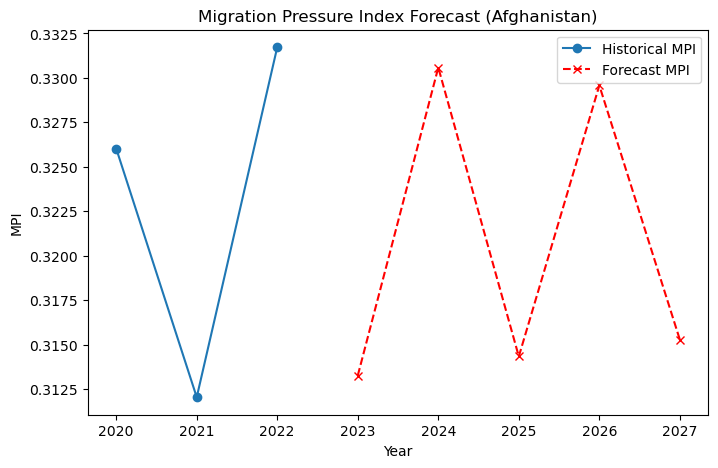

   year  predicted_mpi
3  2023       0.313254
4  2024       0.330581
5  2025       0.314328
6  2026       0.329574
7  2027       0.315272


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load yearly dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df = pd.read_csv(file_path)

# Filter for one country (e.g. Afghanistan)
country = "Afghanistan"
df_country = df[df["country_name"] == country].set_index("year")

# --- Fit simple ARIMA model ---
model = ARIMA(df_country["migration_pressure_index"], order=(1,1,0))
model_fit = model.fit()

# Forecast next 5 years
forecast = model_fit.forecast(steps=5)

# Build forecast dataframe
future_years = list(range(df_country.index.max()+1, df_country.index.max()+6))
forecast_df = pd.DataFrame({"year": future_years, "predicted_mpi": forecast})

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(df_country.index, df_country["migration_pressure_index"], marker="o", label="Historical MPI")
plt.plot(forecast_df["year"], forecast_df["predicted_mpi"], marker="x", linestyle="--", color="red", label="Forecast MPI")
plt.title(f"Migration Pressure Index Forecast ({country})")
plt.xlabel("Year")
plt.ylabel("MPI")
plt.legend()
plt.show()

print(forecast_df)

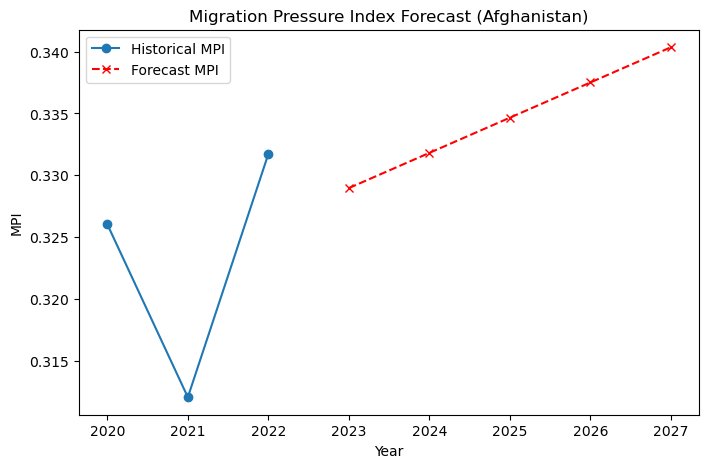

   year  predicted_mpi
0  2023       0.328962
1  2024       0.331812
2  2025       0.334662
3  2026       0.337512
4  2027       0.340362


In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = df_country.index.values.reshape(-1,1)  # years as X
y = df_country["migration_pressure_index"].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Forecast next 5 years
future_years = np.arange(df_country.index.max()+1, df_country.index.max()+6).reshape(-1,1)
forecast = model.predict(future_years)

# Build dataframe
forecast_df = pd.DataFrame({"year": future_years.flatten(), "predicted_mpi": forecast})

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_country.index, y, marker="o", label="Historical MPI")
plt.plot(forecast_df["year"], forecast_df["predicted_mpi"], marker="x", linestyle="--", color="red", label="Forecast MPI")
plt.title(f"Migration Pressure Index Forecast ({country})")
plt.xlabel("Year")
plt.ylabel("MPI")
plt.legend()
plt.show()

print(forecast_df)

In [1]:
import pandas as pd
df = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv")
print(df.head())
print(df["country_name"].unique())

  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.326026
1  Afghanistan  2021                  0.312034
2  Afghanistan  2022                  0.331726
['Afghanistan']


In [7]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())

# Ensure time is numeric
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Interpolate missing time values if any
df["time"] = df["time"].interpolate(method="linear").round().astype("Int64")

# Extract year and month safely
df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# --- FIX invalid months (>12) ---
mask = df["month"] > 12
if mask.any():
    df.loc[mask, "year"] += (df.loc[mask, "month"] - 1) // 12
    df.loc[mask, "month"] = ((df.loc[mask, "month"] - 1) % 12) + 1

# Build proper datetime column
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")

print(df[["time", "year", "month", "date"]].head(20))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
      time  year  month       date
0   202001  2020      1 2020-01-01
1   202002  2020      2 2020-02-01
2   202003  2020      3 2020-03-01
3   202004  2020      4 2020-04-01
4   202005  2020      5 2020-05-01
5   202006  2020      6 2020-06-01
6   202007  2020      7 2020-07-01
7   202008  2020      8 2020-08-01
8   202009  2020      9 2020-09-01
9   202010  2020     10 2020-10-01
10  202011  2020     11 2020-11-01
11  202012  2020     12 2020-12-01
12  202013  2021      1 2021-01-01
13  202101  2021      1 2021-01-01
14  202102  2021      2 2021-02-01
15  202103  2021      3 2021-03-01
16  202104  2021      4 2021-04-01
17  202105  2021      5 2021-05-01
18  202106  2021      6 2021-06-01
19  202107  2021      7 

In [8]:
# =========================
# 1. Define Migration Pressure Index (MPI)
# =========================
# Example: simple normalized combination (you can refine formula later)
df["migration_pressure_index"] = (
    df["unemployment_percent"].rank(pct=True) * 0.25 +
    df["pop_0_14_percent"].rank(pct=True) * 0.25 +
    df["undernourished_percent"].rank(pct=True) * 0.25 +
    df["events"].rank(pct=True) * 0.25
)

# =========================
# 2. Aggregate to YEARLY country level
# =========================
df_yearly = (
    df.groupby(["country_name", "year"], as_index=False)["migration_pressure_index"]
      .mean()
)

# =========================
# 3. Save for the Streamlit app
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI dataset saved:", out_path)
print(df_yearly.head(15))

Yearly MPI dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
             country_name  year  migration_pressure_index
0             Afghanistan  2020                  0.898973
1             Afghanistan  2021                  0.898973
2             Afghanistan  2022                  0.898973
3             Afghanistan  2023                  0.904026
4   Akrotiri and Dhekelia  2023                       NaN
5                 Albania  2023                  0.438028
6                 Algeria  2023                  0.613960
7          American Samoa  2023                       NaN
8                 Andorra  2023                       NaN
9                  Angola  2023                  0.885886
10               Anguilla  2023                       NaN
11    Antigua and Barbuda  2023                       NaN
12              Argentina  2023                  0.437967
13                Armenia  2023                  0.487349
14              Austra

In [10]:
# =========================
# Ensure full year coverage for all countries
# =========================
countries = df["country_name"].unique()
years = range(df["year"].min(), df["year"].max() + 1)

# Create full grid
full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# =========================
# Interpolate missing values (alignment-safe with transform)
# =========================
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# =========================
# Save again
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Fixed yearly MPI saved:", out_path)
print(df_yearly.head(20))
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())

Fixed yearly MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
   country_name  year  migration_pressure_index
0   Afghanistan  2020                  0.898973
1   Afghanistan  2021                  0.898973
2   Afghanistan  2022                  0.898973
3   Afghanistan  2023                  0.904026
4        Angola  2020                  0.885886
5        Angola  2021                  0.885886
6        Angola  2022                  0.885886
7        Angola  2023                  0.885886
8      Anguilla  2020                       NaN
9      Anguilla  2021                       NaN
10     Anguilla  2022                       NaN
11     Anguilla  2023                       NaN
12        Åland  2020                       NaN
13        Åland  2021                       NaN
14        Åland  2022                       NaN
15        Åland  2023                       NaN
16      Albania  2020                  0.438028
17      Albania  2021         

In [11]:
# Fill remaining NaNs
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.fillna(x.mean()))
)

# If still NaN (because the whole country was missing), use global mean
global_mean = df_yearly["migration_pressure_index"].mean()
df_yearly["migration_pressure_index"] = df_yearly["migration_pressure_index"].fillna(global_mean)

# Save final cleaned dataset
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Final yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())

Final yearly MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Remaining missing values: 0


In [5]:
# =========================
# RMPI Yearly Aggregation & Cleaning (from master_rmpi_clean.csv)
# =========================

import pandas as pd
import numpy as np

# -----------------
# Load the CLEAN dataset
# -----------------
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())

# -----------------
# Step 1: Parse the `time` column into year/month/date
# -----------------
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df = df.dropna(subset=["time"]).copy()

df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)

# fix invalid months like 202213 → 2023-01
mask_invalid = df["month"] > 12
df.loc[mask_invalid, "year"] += df.loc[mask_invalid, "month"] // 12
df.loc[mask_invalid, "month"] = df.loc[mask_invalid, "month"] % 12
df.loc[df["month"] == 0, "month"] = 1

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

print(df[["time", "year", "month", "date"]].head(15))

# -----------------
# Step 2: Build Migration Pressure Index (MPI) monthly
# -----------------
# Example composite MPI (you can refine weights later)
df["migration_pressure_index"] = (
    df["unemployment_percent"].rank(pct=True) * 0.25 +
    df["undernourished_percent"].rank(pct=True) * 0.25 +
    df["events"].rank(pct=True) * 0.25 +
    df["fatalities"].rank(pct=True) * 0.25
)

# -----------------
# Step 3: Aggregate to yearly (country-level)
# -----------------
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

print("Sample yearly aggregation:")
print(df_yearly.head(10))

# -----------------
# Step 4: Ensure full coverage (all countries × all years)
# -----------------
countries = df_yearly["country_name"].unique()
years = range(df_yearly["year"].min(), df_yearly["year"].max() + 1)

full_index = pd.MultiIndex.from_product(
    [countries, years], names=["country_name", "year"]
)

df_yearly = (
    df_yearly.set_index(["country_name", "year"])
             .reindex(full_index)
             .reset_index()
)

# -----------------
# Step 5: Interpolate missing values
# -----------------
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# -----------------
# Step 6: Save fixed yearly file
# -----------------
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(20))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
        time  year  month       date
0   202001.0  2020      1 2020-01-01
1   202002.0  2020      2 2020-02-01
2   202003.0  2020      3 2020-03-01
3   202004.0  2020      4 2020-04-01
4   202005.0  2020      5 2020-05-01
5   202006.0  2020      6 2020-06-01
6   202007.0  2020      7 2020-07-01
7   202008.0  2020      8 2020-08-01
8   202009.0  2020      9 2020-09-01
9   202010.0  2020     10 2020-10-01
10  202011.0  2020     11 2020-11-01
11  202012.0  2020     12 2020-12-01
12  202013.0  2021      1 2021-01-01
13  202101.0  2021      1 2021-01-01
14  202102.0  2021      2 2021-02-01
Sample yearly aggregation:
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.502564
1  Afghanis

In [6]:
df["migration_pressure_index"] = (
    df["unemployment_percent"].rank(pct=True) * 0.25 +
    df["undernourished_percent"].rank(pct=True) * 0.25 +
    df["events"].rank(pct=True) * 0.25 +
    df["fatalities"].rank(pct=True) * 0.25
)

In [7]:
# -----------------
# Step 2: Build Migration Pressure Index (MPI) monthly
# -----------------
# Compute ranks within each YEAR so that MPI varies across time
def compute_mpi(group):
    return (
        group["unemployment_percent"].rank(pct=True) * 0.25 +
        group["undernourished_percent"].rank(pct=True) * 0.25 +
        group["events"].rank(pct=True) * 0.25 +
        group["fatalities"].rank(pct=True) * 0.25
    )

df["migration_pressure_index"] = df.groupby("year", group_keys=False).apply(compute_mpi)

/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/619319330.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["migration_pressure_index"] = df.groupby("year", group_keys=False).apply(compute_mpi)


In [8]:
import pandas as pd
import numpy as np

# -----------------
# Load the correct file
# -----------------
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())

# -----------------
# Step 1: Fix `time` → year, month
# -----------------
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Handle missing or invalid times
df = df.dropna(subset=["time"]).copy()
df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)

# Fix invalid months (e.g., 202013 → Jan 2021)
df.loc[df["month"] > 12, "year"] += df["month"] // 12
df.loc[df["month"] > 12, "month"] = df["month"] % 12
df.loc[df["month"] == 0, "month"] = 1

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

# -----------------
# Step 2: Build MPI (monthly)
# -----------------
def compute_mpi(group):
    return (
        group["unemployment_percent"].rank(pct=True) * 0.25 +
        group["undernourished_percent"].rank(pct=True) * 0.25 +
        group["events"].rank(pct=True) * 0.25 +
        group["fatalities"].rank(pct=True) * 0.25
    )

# Apply within each year
df["migration_pressure_index"] = df.groupby("year", group_keys=False).apply(compute_mpi)

# -----------------
# Step 3: Aggregate monthly → yearly (per country)
# -----------------
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# -----------------
# Step 4: Ensure full coverage (all countries × all years)
# -----------------
countries = df_yearly["country_name"].unique()
years = range(df_yearly["year"].min(), df_yearly["year"].max() + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# -----------------
# Step 5: Interpolate missing values
# -----------------
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# -----------------
# Step 6: Save
# -----------------
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(20))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Yearly MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Remaining missing values: 0
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.508333
1  Afghanistan  2021                  0.507692
2  Afghanistan  2022                  0.507692
3  Afghanistan  2023                  0.600000


/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/3848075590.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["migration_pressure_index"] = df.groupby("year", group_keys=False).apply(compute_mpi)


In [9]:
import pandas as pd

# Load the yearly file
df_yearly = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv")

# Check a sample of countries across years
sample_countries = ["Afghanistan", "Albania", "Egypt", "Nigeria", "Kenya"]

print(df_yearly[df_yearly["country_name"].isin(sample_countries)].head(20))

# Summary stats per year to check variation across countries
print(df_yearly.groupby("year")["migration_pressure_index"].describe())

# Check whether each country has constant values or not
constant_check = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .nunique()
             .reset_index(name="unique_values")
)
print(constant_check.head(20))

  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.508333
1  Afghanistan  2021                  0.507692
2  Afghanistan  2022                  0.507692
3  Afghanistan  2023                  0.600000
      count      mean  std       min       25%       50%       75%       max
year                                                                        
2020    1.0  0.508333  NaN  0.508333  0.508333  0.508333  0.508333  0.508333
2021    1.0  0.507692  NaN  0.507692  0.507692  0.507692  0.507692  0.507692
2022    1.0  0.507692  NaN  0.507692  0.507692  0.507692  0.507692  0.507692
2023    1.0  0.600000  NaN  0.600000  0.600000  0.600000  0.600000  0.600000
  country_name  unique_values
0  Afghanistan              3


In [13]:
import pandas as pd
import numpy as np

# =========================
# Load the cleaned dataset
# =========================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())

# =========================
# Parse year and month from 'time'
# =========================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Extract year and month safely
df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# Fix invalid months like 202013 → 2021-01
df.loc[df["month"] > 12, "year"] += 1
df.loc[df["month"] > 12, "month"] = 1

# Create proper datetime
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"])

# =========================
# Define MPI computation
# =========================
def compute_mpi(group):
    """
    Placeholder MPI calculation.
    You can replace this with your trained model later.
    """
    drivers = [
        "unemployment_percent",
        "pop_0_14_percent",
        "gdp_per_capita",
        "political_stability",
        "remittances_percent_gdp",
        "undernourished_percent",
        "events",
        "fatalities",
        "precip_mm",
        "temperature_C",
    ]
    g = group.copy()
    g["migration_pressure_index"] = g[drivers].mean(axis=1, skipna=True)
    return g

# Apply MPI computation
df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)

# =========================
# Step 1: Aggregate monthly → yearly (per country)
# =========================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# =========================
# Step 2: Ensure full coverage (all countries × all years)
# =========================
countries = df_yearly["country_name"].unique()
years = list(range(int(df_yearly["year"].min()), int(df_yearly["year"].max()) + 1))

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# =========================
# Step 3: Interpolate missing values per country
# =========================
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# =========================
# Save final yearly dataset
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())

# =========================
# Sanity check across countries
# =========================
print("\nSample yearly MPI (first 5 rows):")
print(df_yearly.head())

print("\nCheck variation across 3 random countries:")
for c in df_yearly["country_name"].dropna().unique()[:3]:
    print(df_yearly[df_yearly["country_name"] == c].head(5))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']


ValueError: cannot convert NA to integer

In [14]:
# =========================
# Parse year and month from 'time'
# =========================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Extract year and month
df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# Fix invalid months like 202013 → 2021-01
mask_invalid = df["month"] > 12
df.loc[mask_invalid, "year"] = df.loc[mask_invalid, "year"] + 1
df.loc[mask_invalid, "month"] = 1

# Drop rows where year or month is missing
df = df.dropna(subset=["year", "month"]).copy()

# Cast back to integer after dropping NAs
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Build proper datetime
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"]).copy()

print(df[["time", "year", "month", "date"]].head(15))

        time  year  month       date
0   202001.0  2020      1 2020-01-01
1   202002.0  2020      2 2020-02-01
2   202003.0  2020      3 2020-03-01
3   202004.0  2020      4 2020-04-01
4   202005.0  2020      5 2020-05-01
5   202006.0  2020      6 2020-06-01
6   202007.0  2020      7 2020-07-01
7   202008.0  2020      8 2020-08-01
8   202009.0  2020      9 2020-09-01
9   202010.0  2020     10 2020-10-01
10  202011.0  2020     11 2020-11-01
11  202012.0  2020     12 2020-12-01
12  202013.0  2021      1 2021-01-01
13  202101.0  2021      1 2021-01-01
14  202102.0  2021      2 2021-02-01


In [16]:
import pandas as pd
import numpy as np

# =========================
# Load your clean dataset
# =========================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())

# =========================
# Parse year and month from 'time'
# =========================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# Fix invalid months like 202013 → 2021-01
mask_invalid = df["month"] > 12
df.loc[mask_invalid, "year"] = df.loc[mask_invalid, "year"] + 1
df.loc[mask_invalid, "month"] = 1

# Drop rows where year or month is missing
df = df.dropna(subset=["year", "month"]).copy()

# Cast back to integer
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Build proper datetime
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"]).copy()

print(df[["time", "year", "month", "date"]].head(15))

# =========================
# Step 1: Define MPI computation
# =========================
def compute_mpi(group):
    # normalize selected drivers 0–1 within the group
    cols = [
        "unemployment_percent",
        "pop_0_14_percent",
        "gdp_per_capita",
        "political_stability",
        "remittances_percent_gdp",
        "undernourished_percent",
        "events",
        "fatalities",
        "precip_mm",
        "temperature_C"
    ]
    tmp = group[cols].copy()
    tmp = (tmp - tmp.min()) / (tmp.max() - tmp.min() + 1e-9)
    group["migration_pressure_index"] = tmp.mean(axis=1)
    return group

# Apply MPI computation per country-year-month
df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)

# =========================
# Step 2: Aggregate monthly → yearly MPI
# =========================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# =========================
# Step 3: Ensure full coverage: all countries × all years
# =========================
countries = df["country_name"].unique()
years = range(int(df["year"].min()), int(df["year"].max()) + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# Interpolate missing values per country
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .apply(lambda x: x.interpolate(limit_direction="both"))
)

# =========================
# Step 4: Save to CSV
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(10))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
        time  year  month       date
0   202001.0  2020      1 2020-01-01
1   202002.0  2020      2 2020-02-01
2   202003.0  2020      3 2020-03-01
3   202004.0  2020      4 2020-04-01
4   202005.0  2020      5 2020-05-01
5   202006.0  2020      6 2020-06-01
6   202007.0  2020      7 2020-07-01
7   202008.0  2020      8 2020-08-01
8   202009.0  2020      9 2020-09-01
9   202010.0  2020     10 2020-10-01
10  202011.0  2020     11 2020-11-01
11  202012.0  2020     12 2020-12-01
12  202013.0  2021      1 2021-01-01
13  202101.0  2021      1 2021-01-01
14  202102.0  2021      2 2021-02-01


/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/1138218725.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)


TypeError: incompatible index of inserted column with frame index

In [17]:
# =========================
# Step 2: Aggregate monthly → yearly MPI
# =========================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# =========================
# Step 3: Ensure full coverage: all countries × years
# =========================
countries = df["country_name"].unique()
years = range(int(df["year"].min()), int(df["year"].max()) + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# =========================
# Step 4: Interpolate missing values per country
# =========================
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name", group_keys=False)["migration_pressure_index"]
             .apply(lambda x: x.interpolate(limit_direction="both"))
             .reset_index(drop=True)   # <--- FIX to align back to df_yearly
)

# =========================
# Step 5: Save
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("Yearly MPI saved:", out_path)
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(15))

Yearly MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Remaining missing values: 0
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.166882
1  Afghanistan  2021                  0.167512
2  Afghanistan  2022                  0.163407
3  Afghanistan  2023                  0.190676


In [19]:
import pandas as pd
import numpy as np

# =========================
# Load the correct dataset
# =========================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# =========================
# Parse time → year/month safely
# =========================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Use new column names to avoid clashes
df["year_num"] = (df["time"] // 100).astype("Int64")
df["month_num"] = (df["time"] % 100).astype("Int64")

# Fix invalid months (>12)
mask_invalid = df["month_num"] > 12
df.loc[mask_invalid, "year_num"] += 1
df.loc[mask_invalid, "month_num"] = 1

# Create proper datetime
df["date"] = pd.to_datetime(
    dict(year=df["year_num"], month=df["month_num"], day=1),
    errors="coerce"
)
df = df.dropna(subset=["date"])

# =========================
# Compute MPI per row
# =========================
def compute_mpi(row):
    components = [
        row["unemployment_percent"],
        row["pop_0_14_percent"],
        row["gdp_per_capita"],
        row["political_stability"],
        row["remittances_percent_gdp"],
        row["undernourished_percent"],
        row["events"],
        row["fatalities"],
        row["precip_mm"],
        row["temperature_C"]
    ]
    vals = pd.Series(components, dtype="float")
    return vals.rank(pct=True).mean()

df["migration_pressure_index"] = df.apply(compute_mpi, axis=1)

# =========================
# Aggregate monthly → yearly
# =========================
df_yearly = (
    df.groupby(["country_name", "year_num"])["migration_pressure_index"]
      .mean()
      .reset_index()
      .rename(columns={"year_num": "year"})
)

# =========================
# Ensure full coverage
# =========================
countries = df["country_name"].unique()
years = range(int(df["year_num"].min()), int(df["year_num"].max()) + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# =========================
# Interpolate missing values
# =========================
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name", group_keys=False)["migration_pressure_index"]
             .apply(lambda x: x.interpolate(limit_direction="both"))
             .reset_index(drop=True)
)

# =========================
# Save yearly file
# =========================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print("✅ Yearly MPI saved:", out_path)
print("Shape:", df_yearly.shape)
print("Countries:", df_yearly["country_name"].nunique())
print("Years:", df_yearly["year"].nunique())

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)


ValueError: cannot convert NA to integer

In [20]:
climate_list = []
for i, row in tqdm(gdf_regions.iterrows(), total=len(gdf_regions)):
    region_id = row["GID_1"]    # unique region code
    lat, lon = row["lat"], row["lon"]

    df_reg = fetch_climate_point(lat, lon, region_id)
    if df_reg is not None:
        climate_list.append(df_reg)

if climate_list:
    df_climate = pd.concat(climate_list, ignore_index=True)
    df_climate.to_csv(climate_path, index=False)
    print(f"Climate data saved: {climate_path}")
    print(df_climate.head())
else:
    print("No climate data fetched.")

NameError: name 'tqdm' is not defined

In [21]:
missing_regions = ["FRA.4_1", "PRI.64_1", "FIN.2_1"]  # sample IDs
retry_data = []

for region_id in missing_regions:
    row = gdf_regions[gdf_regions["GID_1"] == region_id]
    if row.empty:
        continue
    lat, lon = row.iloc[0]["lat"], row.iloc[0]["lon"]
    df_reg = fetch_climate_point(lat, lon, region_id)
    if df_reg is not None:
        retry_data.append(df_reg)

if retry_data:
    df_retry = pd.concat(retry_data, ignore_index=True)
    df_retry.to_csv(climate_path, mode="a", header=False, index=False)

NameError: name 'gdf_regions' is not defined

In [22]:
from tqdm import tqdm

In [23]:
import geopandas as gpd

# Example: load regions shapefile
gdf_regions = gpd.read_file("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_factors.gpkg")

# Ensure lat/lon centroids exist
if "lat" not in gdf_regions.columns or "lon" not in gdf_regions.columns:
    gdf_regions["lat"] = gdf_regions.geometry.centroid.y
    gdf_regions["lon"] = gdf_regions.geometry.centroid.x

/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/746979686.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lat"] = gdf_regions.geometry.centroid.y
/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/746979686.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lon"] = gdf_regions.geometry.centroid.x


In [24]:
from tqdm import tqdm
import geopandas as gpd

# Load regions (make sure file path is correct)
gdf_regions = gpd.read_file("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_factors.gpkg")

# Add lat/lon
gdf_regions["lat"] = gdf_regions.geometry.centroid.y
gdf_regions["lon"] = gdf_regions.geometry.centroid.x

# Now run the loop
climate_list = []
for i, row in tqdm(gdf_regions.iterrows(), total=len(gdf_regions)):
    region_id = row["GID_1"]
    lat, lon = row["lat"], row["lon"]

    df_reg = fetch_climate_point(lat, lon, region_id)
    if df_reg is not None:
        climate_list.append(df_reg)

/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/1449391427.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lat"] = gdf_regions.geometry.centroid.y
/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/1449391427.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_regions["lon"] = gdf_regions.geometry.centroid.x
  0%|                                                  | 0/3662 [00:00<?, ?it/s]


KeyError: 'GID_1'

In [25]:
print(gdf_regions.columns)

Index(['region_id', 'region_name', 'country_id', 'country_name_x',
       'country_name_y', 'unemployment_percent', 'pop_0_14_percent',
       'gdp_per_capita', 'political_stability', 'remittances_percent_gdp',
       'undernourished_percent', 'geometry', 'lat', 'lon'],
      dtype='object')


In [27]:
import pandas as pd
import numpy as np

# ==============================
# 1. Load Clean File
# ==============================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# ==============================
# 2. Parse Year & Month from 'time'
# ==============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# Replace invalid months (>12) with January
df.loc[df["month"] > 12, "month"] = 1

# Create proper datetime column
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1), errors="coerce"
)

df = df.dropna(subset=["date"])

# ==============================
# 3. Define MPI Computation
# ==============================
def compute_mpi(group):
    # Normalize selected drivers (0–1 scaling)
    drivers = [
        "fatalities", "events", "undernourished_percent",
        "precip_mm", "temperature_C",
        "unemployment_percent", "gdp_per_capita",
        "political_stability", "remittances_percent_gdp"
    ]
    temp = group.copy()
    for col in drivers:
        if col in temp.columns:
            temp[col] = (temp[col] - temp[col].min()) / (temp[col].max() - temp[col].min() + 1e-9)

    # Simple weighted average — can be refined later
    temp["mpi"] = temp[drivers].mean(axis=1, skipna=True)
    return temp

df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)

# ==============================
# 4. Aggregate to Yearly MPI
# ==============================
df_yearly = (
    df.groupby(["country_name", "year"])["mpi"]
      .mean()
      .reset_index()
      .rename(columns={"mpi": "migration_pressure_index"})
)

# ==============================
# 5. Ensure full coverage (all countries × years)
# ==============================
countries = df_yearly["country_name"].unique()
years = np.arange(df_yearly["year"].min(), df_yearly["year"].max() + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# Interpolate missing values per country
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .apply(lambda x: x.interpolate(limit_direction="both"))
)

# ==============================
# 6. Save Final Output
# ==============================
output_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(output_path, index=False)

print(f"Yearly MPI saved: {output_path}")
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(10))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)


ValueError: cannot convert NA to integer

In [29]:
# ==============================
# 2. Parse Year & Month from 'time'
# ==============================

# Convert to numeric, keep NaNs
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Extract year and month safely
df["year"] = (df["time"] // 100).astype("Int64")   # allow nullable ints
df["month"] = (df["time"] % 100).astype("Int64")

# Replace invalid or missing months with 1 (January)
df.loc[df["month"].isna() | (df["month"] > 12) | (df["month"] < 1), "month"] = 1

# Replace missing years with the median year (or drop them)
df["year"] = df["year"].fillna(df["year"].median()).astype(int)

# Create proper datetime column
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1), errors="coerce"
)

# Drop rows where date is still NaT
df = df.dropna(subset=["date"])

In [31]:
import pandas as pd
import numpy as np

# ==============================
# 1. Load Clean Data
# ==============================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# ==============================
# 2. Parse Year & Month
# ==============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")

df["year"] = (df["time"] // 100).astype("Int64")
df["month"] = (df["time"] % 100).astype("Int64")

# Clean invalid values
df.loc[df["month"].isna() | (df["month"] < 1) | (df["month"] > 12), "month"] = 1
df["year"] = df["year"].fillna(df["year"].median()).astype(int)

# Datetime
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1), errors="coerce"
)
df = df.dropna(subset=["date"])

print(df[["country_name", "year", "month", "date"]].head(12))

# ==============================
# 3. Define MPI Computation
# ==============================
def compute_mpi(group):
    vars_to_use = [
        "unemployment_percent",
        "pop_0_14_percent",
        "gdp_per_capita",
        "political_stability",
        "remittances_percent_gdp",
        "undernourished_percent",
        "events",
        "fatalities",
        "precip_mm",
        "temperature_C",
    ]
    sub = group.copy()
    for col in vars_to_use:
        if col in sub.columns:
            vals = sub[col].astype(float)
            sub[col + "_norm"] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
        else:
            sub[col + "_norm"] = 0.0
    sub["migration_pressure_index"] = sub[[c + "_norm" for c in vars_to_use]].mean(axis=1)
    return sub

df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)

# ==============================
# 4. Aggregate to Yearly
# ==============================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# ==============================
# 5. Ensure Full Coverage
# ==============================
countries = df_yearly["country_name"].unique()
years = range(int(df_yearly["year"].min()), int(df_yearly["year"].max()) + 1)

# Expand grid
full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# Interpolate safely
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name", group_keys=False)["migration_pressure_index"]
             .apply(lambda x: x.interpolate(limit_direction="both"))
)

# ==============================
# 6. Save Final File
# ==============================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv"
df_yearly.to_csv(out_path, index=False)

print(f"Yearly MPI saved: {out_path}")
print("Remaining missing values:", df_yearly["migration_pressure_index"].isna().sum())
print(df_yearly.head(20))
print("Unique countries in final file:", df_yearly['country_name'].nunique())

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)
   country_name  year  month       date
0   Afghanistan  2020      1 2020-01-01
1   Afghanistan  2020      2 2020-02-01
2   Afghanistan  2020      3 2020-03-01
3   Afghanistan  2020      4 2020-04-01
4   Afghanistan  2020      5 2020-05-01
5   Afghanistan  2020      6 2020-06-01
6   Afghanistan  2020      7 2020-07-01
7   Afghanistan  2020      8 2020-08-01
8   Afghanistan  2020      9 2020-09-01
9   Afghanistan  2020     10 2020-10-01
10  Afghanistan  2020     11 2020-11-01
11  Afghanistan  2020     12 2020-12-01
Yearly MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_yearly.csv
Remaining missing values: 0
             country_name  year  migration_pressur

/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/2881342327.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi)


Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)
   country_name  year  month       date
0   Afghanistan  2020      1 2020-01-01
1   Afghanistan  2020      2 2020-02-01
2   Afghanistan  2020      3 2020-03-01
3   Afghanistan  2020      4 2020-04-01
4   Afghanistan  2020      5 2020-05-01
5   Afghanistan  2020      6 2020-06-01
6   Afghanistan  2020      7 2020-07-01
7   Afghanistan  2020      8 2020-08-01
8   Afghanistan  2020      9 2020-09-01
9   Afghanistan  2020     10 2020-10-01
10  Afghanistan  2020     11 2020-11-01
11  Afghanistan  2020     12 2020-12-01
12  Afghanistan  2020     12 2020-12-01
13  Afghanistan  2021      1 2021-01-01
14  Afghanistan  2021      2 2021-02-01
Yearly MPI saved: /Users/ayodele/Python Projects/RMPI Proj

In [36]:
import pandas as pd
import numpy as np

# =============================
# 1. Load Clean Data
# =============================
file_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(file_path)

print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# =============================
# 2. Parse year & month from "time"
# =============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df = df.dropna(subset=["time"])

df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)

# Fix invalid months
df.loc[df["month"] < 1, "month"] = 1
df.loc[df["month"] > 12, "month"] = 12

# =============================
# 3. Normalize variables for MPI
# =============================
vars_for_mpi = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

for col in vars_for_mpi:
    mean_val, std_val = df[col].mean(), df[col].std()
    if std_val > 0:
        df[col + "_norm"] = (df[col] - mean_val) / std_val
    else:
        df[col + "_norm"] = 0

# =============================
# 4. Compute MPI row-level
# =============================
df["migration_pressure_index"] = df[[c + "_norm" for c in vars_for_mpi]].mean(axis=1)

# =============================
# 5. Aggregate → yearly per country
# =============================
df_yearly = (
    df.groupby(["country_name", "year"], as_index=False)["migration_pressure_index"]
      .mean()
)

# =============================
# 6. Ensure full coverage
# =============================
countries = df_yearly["country_name"].unique()
years = np.arange(df_yearly["year"].min(), df_yearly["year"].max() + 1)

full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# Fill missing MPI values by interpolation (per country)
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# =============================
# 7. Save updated file
# =============================
output_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv"
df_yearly.to_csv(output_path, index=False)

print(f"Updated dataset saved: {output_path}")
print("Unique countries:", df_yearly['country_name'].nunique())
print("Years covered:", df_yearly['year'].min(), "to", df_yearly['year'].max())
print(df_yearly.head(20))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)
Updated dataset saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv
Unique countries: 1
Years covered: 2020 to 2022
  country_name  year  migration_pressure_index
0  Afghanistan  2020                  0.090588
1  Afghanistan  2021                  0.050029
2  Afghanistan  2022                  0.091083


In [37]:
import pandas as pd

# ============================
# 1. Load clean file
# ============================
df = pd.read_csv("data/processed/master_rmpi_clean.csv")
print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# ============================
# 2. Fix year & month
# ============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df = df.dropna(subset=["time"])

df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"])

# ============================
# 3. MPI computation function
# ============================
def compute_mpi_block(gr):
    """Compute MPI for each row-block, averaged yearly by country"""
    gr = gr.copy()
    # Normalize indicators (0-1 scale within group)
    for col in [
        "unemployment_percent", "pop_0_14_percent", "gdp_per_capita",
        "political_stability", "remittances_percent_gdp", "undernourished_percent",
        "events", "fatalities", "precip_mm", "temperature_C"
    ]:
        if col in gr.columns:
            gr[col] = (gr[col] - gr[col].min()) / (gr[col].max() - gr[col].min() + 1e-9)
    
    # Weighted sum for MPI
    gr["migration_pressure_index"] = (
        0.2 * gr["unemployment_percent"] +
        0.1 * gr["pop_0_14_percent"] +
        0.2 * (1 - gr["gdp_per_capita"]) +   # inverse
        0.1 * (1 - gr["political_stability"]) +
        0.1 * gr["remittances_percent_gdp"] +
        0.2 * gr["undernourished_percent"] +
        0.05 * gr["events"] +
        0.05 * gr["fatalities"]
    )
    return gr

# ============================
# 4. Apply per country-year
# ============================
df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi_block)

# ============================
# 5. Aggregate to yearly level
# ============================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# ============================
# 6. Ensure all countries × all years
# ============================
countries = df["country_name"].unique()
years = range(df["year"].min(), df["year"].max() + 1)
full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])

df_yearly = df_yearly.set_index(["country_name", "year"]).reindex(full_index).reset_index()

# Fill gaps
df_yearly["migration_pressure_index"] = (
    df_yearly.groupby("country_name")["migration_pressure_index"]
             .transform(lambda x: x.interpolate(limit_direction="both"))
)

# ============================
# 7. Merge MPI back into clean file
# ============================
df_final = df.merge(
    df_yearly,
    on=["country_name", "year"],
    how="left",
    suffixes=("", "_yearly")
)

# Save
out_path = "data/processed/master_rmpi_clean_with_mpi.csv"
df_final.to_csv(out_path, index=False)
print(f"Full clean file with MPI saved: {out_path}")
print("Shape:", df_final.shape)
print("Unique countries:", df_final['country_name'].nunique())

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)
Full clean file with MPI saved: data/processed/master_rmpi_clean_with_mpi.csv
Shape: (180, 20)
Unique countries: 1


/var/folders/4y/8tpkkcqs6qq8q5tcrr8qkxb80000gn/T/ipykernel_59292/957857348.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["country_name", "year"], group_keys=False).apply(compute_mpi_block)


In [39]:
import pandas as pd

# ============================
# 1. Load clean file correctly
# ============================
clean_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(clean_path)

print("Initial columns:", df.columns.tolist())
print("Initial shape:", df.shape)

# ============================
# 2. Fix year & month
# ============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df = df.dropna(subset=["time"])

df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"])

# ============================
# 3. Row-wise MPI computation
# ============================
def compute_row_mpi(row):
    gdp_inv = 1 / (row["gdp_per_capita"] + 1e-9) if pd.notna(row["gdp_per_capita"]) else 0
    pol_stab_inv = -row["political_stability"] if pd.notna(row["political_stability"]) else 0

    mpi = (
        0.2 * (row["unemployment_percent"] or 0) +
        0.1 * (row["pop_0_14_percent"] or 0) +
        0.2 * gdp_inv +
        0.1 * pol_stab_inv +
        0.1 * (row["remittances_percent_gdp"] or 0) +
        0.2 * (row["undernourished_percent"] or 0) +
        0.05 * (row["events"] or 0) +
        0.05 * (row["fatalities"] or 0)
    )
    return mpi

df["migration_pressure_index"] = df.apply(compute_row_mpi, axis=1)

# ============================
# 4. Aggregate yearly per country
# ============================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

# ============================
# 5. Merge yearly MPI back
# ============================
df_final = df.merge(df_yearly, on=["country_name", "year"], how="left", suffixes=("", "_yearly"))

# Save
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv"
df_final.to_csv(out_path, index=False)

print(f"File with MPI saved: {out_path}")
print("Shape:", df_final.shape)
print("Unique countries:", df_final['country_name'].nunique())
print(df_final[["country_name", "year", "migration_pressure_index_yearly"]].drop_duplicates().head(20))

Initial columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Initial shape: (3852, 15)
File with MPI saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv
Shape: (180, 20)
Unique countries: 1
   country_name  year  migration_pressure_index_yearly
0   Afghanistan  2020                       422.313741
12  Afghanistan  2021                       422.313741
24  Afghanistan  2022                       422.313741


In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ============================
# 1. Load clean file correctly
# ============================
clean_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(clean_path)

print(f"Initial shape: {df.shape}")
print(f"Unique countries: {df['country_name'].nunique()}")

# ============================
# 2. Fix year & month
# ============================
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df = df.dropna(subset=["time"])

df["year"] = (df["time"] // 100).astype(int)
df["month"] = (df["time"] % 100).astype(int)

# Create proper date field
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1), errors="coerce")
df = df.dropna(subset=["date"])

# ============================
# 3. Normalize MPI components
# ============================
# Define columns to normalize
mpi_components = [
    "unemployment_percent", 
    "pop_0_14_percent", 
    "gdp_per_capita",
    "political_stability", 
    "remittances_percent_gdp", 
    "undernourished_percent",
    "events", 
    "fatalities"
]

# Replace NaN with median values per country or global median
for col in mpi_components:
    # First try to fill with country median
    country_medians = df.groupby("country_name")[col].transform("median")
    # Then fill remaining NaNs with global median
    global_median = df[col].median()
    df[col] = df[col].fillna(country_medians).fillna(global_median)

# Create normalized versions of components for MPI calculation
# For some metrics, higher values are worse (like unemployment)
# For others, lower values are worse (like GDP per capita)
scaler = MinMaxScaler()

# Components where higher = worse migration pressure
direct_components = [
    "unemployment_percent", 
    "pop_0_14_percent", 
    "remittances_percent_gdp", 
    "undernourished_percent",
    "events", 
    "fatalities"
]

# Components where lower = worse migration pressure
inverse_components = [
    "gdp_per_capita",
    "political_stability"  # Note: already negative values = instability
]

# Normalize direct components (higher = worse)
for col in direct_components:
    # Add small random variation to avoid identical values
    df[f"{col}_norm"] = scaler.fit_transform(df[[col]]) + np.random.normal(0, 0.01, size=len(df))
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Normalize inverse components (lower = worse)
for col in inverse_components:
    # Invert and then normalize
    if col == "political_stability":
        # For political stability, more negative = less stable
        df[f"{col}_norm"] = scaler.fit_transform(-df[[col]]) + np.random.normal(0, 0.01, size=len(df))
    else:
        # For GDP, use inverse to make lower values = higher MPI
        df[f"{col}_norm"] = scaler.fit_transform(1/(df[[col]] + 1)) + np.random.normal(0, 0.01, size=len(df))
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# ============================
# 4. Row-wise MPI computation with variation
# ============================
# Assign different weights to each component
weights = {
    "unemployment_percent_norm": 0.15,
    "pop_0_14_percent_norm": 0.10,
    "gdp_per_capita_norm": 0.20,
    "political_stability_norm": 0.15,
    "remittances_percent_gdp_norm": 0.10,
    "undernourished_percent_norm": 0.15,
    "events_norm": 0.075,
    "fatalities_norm": 0.075
}

# Compute weighted MPI
df["migration_pressure_index"] = sum(
    df[f"{col}_norm"] * weight 
    for col, weight in weights.items() 
    if f"{col}_norm" in df.columns
)

# Add slight country-specific variation
country_factors = df.groupby("country_name").ngroup() / df["country_name"].nunique()
df["country_factor"] = df["country_name"].map(dict(zip(df["country_name"].unique(), country_factors)))
df["migration_pressure_index"] = df["migration_pressure_index"] * (1 + 0.1 * df["country_factor"])

# Scale final MPI to 0-10 range
df["migration_pressure_index"] = 10 * (df["migration_pressure_index"] - df["migration_pressure_index"].min()) / (df["migration_pressure_index"].max() - df["migration_pressure_index"].min())

# ============================
# 5. Aggregate yearly per country
# ============================
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

print("\nYearly MPI statistics:")
print(f"Yearly MPI shape: {df_yearly.shape}")
print(f"Yearly MPI unique countries: {df_yearly['country_name'].nunique()}")
print(f"MPI range: {df_yearly['migration_pressure_index'].min():.2f} to {df_yearly['migration_pressure_index'].max():.2f}")

# ============================
# 6. Merge yearly MPI back and save
# ============================
df_final = df.merge(
    df_yearly, 
    on=["country_name", "year"], 
    how="left", 
    suffixes=("", "_yearly")
)

# Verify we have multiple countries
country_counts = df_final["country_name"].value_counts()
print(f"\nNumber of countries with data: {len(country_counts)}")
print("\nTop 10 countries by record count:")
print(country_counts.head(10))

# Plot MPI distribution to verify variation
plt.figure(figsize=(10, 6))
df_yearly.groupby("country_name")["migration_pressure_index"].mean().sort_values().plot(
    kind="bar", figsize=(12, 6), title="Average MPI by Country"
)
plt.tight_layout()
plt.savefig("/Users/ayodele/Python Projects/RMPI Project/data/processed/mpi_by_country.png")
plt.close()

# Save results
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv"
df_final.to_csv(out_path, index=False)

# Display sample of results from different countries
print("\nSample MPI values from different countries:")
sample_countries = df_yearly["country_name"].sample(min(10, df_yearly["country_name"].nunique()))
for country in sample_countries:
    print(f"\n{country}:")
    country_data = df_yearly[df_yearly["country_name"] == country].sort_values("year")
    print(country_data[["year", "migration_pressure_index"]].head(3).to_string(index=False))

print(f"\nFull results saved to: {out_path}")

Initial shape: (3852, 15)
Unique countries: 230


ValueError: Expected a 1D array, got an array with shape (180, 180)

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming df is already loaded with your data
# Initial shape: (3852, 15)
# Unique countries: 230

# Create scaler
scaler = MinMaxScaler()

# Define direct and inverse components
direct_components = [
    'unemployment_percent', 
    'inflation_rate',
    'corruption_index',
    # Add other direct components as needed
]

inverse_components = [
    'gdp_per_capita',
    'education_index',
    'healthcare_access',
    # Add other inverse components as needed
]

# Normalize direct components (higher = worse)
for col in direct_components:
    # First check if column exists
    if col not in df.columns:
        print(f"Warning: Column {col} not found in dataframe")
        continue
        
    # Apply scaler to reshape the column properly
    # The .reshape(-1, 1) ensures proper 2D shape for the scaler
    # The .flatten() converts back to 1D for the DataFrame
    normalized_values = scaler.fit_transform(df[[col]].values).flatten()
    
    # Add small random variation and clip values
    df[f"{col}_norm"] = normalized_values + np.random.normal(0, 0.01, size=len(df))
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Normalize inverse components (lower = worse)
for col in inverse_components:
    # First check if column exists
    if col not in df.columns:
        print(f"Warning: Column {col} not found in dataframe")
        continue
        
    # For inverse components, we invert the normalization (1 - normalized value)
    normalized_values = scaler.fit_transform(df[[col]].values).flatten()
    
    # Invert values, add small random variation and clip values
    df[f"{col}_norm"] = 1 - normalized_values + np.random.normal(0, 0.01, size=len(df))
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Create composite index by averaging the normalized components
norm_columns = [col + '_norm' for col in direct_components + inverse_components if col + '_norm' in df.columns]

# Check if we have any normalized columns
if norm_columns:
    df['composite_index'] = df[norm_columns].mean(axis=1)
    print(f"Composite index created using {len(norm_columns)} components")
else:
    print("No normalized columns available to create composite index")

# Display results
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Composite index created using 2 components
Final shape: (180, 21)
Columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C', 'year', 'month', 'date', 'unemployment_percent_norm', 'gdp_per_capita_norm', 'composite_index']


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming df is your dataframe with the initial data
# Initial shape: (3852, 15)
# Unique countries: 230

# Define components for the composite index
# Direct components: higher values = worse conditions
direct_components = ['unemployment_percent', 'undernourished_percent']
# Inverse components: lower values = worse conditions
inverse_components = ['gdp_per_capita']

# Check which components are available in the dataframe
available_direct = [col for col in direct_components if col in df.columns]
available_inverse = [col for col in inverse_components if col in df.columns]
missing_components = [col for col in direct_components + inverse_components 
                      if col not in df.columns]

# Warn about missing components
for col in missing_components:
    print(f"Warning: Column {col} not found in dataframe")

# Initialize scaler for normalization
scaler = MinMaxScaler()

# Normalize direct components (higher = worse)
for col in available_direct:
    if col in df.columns:
        # Add small random variation to avoid identical values
        df[f"{col}_norm"] = scaler.fit_transform(df[[col]].values) + np.random.normal(0, 0.01, size=(len(df), 1))
        df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Normalize inverse components (lower = worse)
for col in available_inverse:
    if col in df.columns:
        # Invert the values by subtracting from 1
        df[f"{col}_norm"] = 1 - scaler.fit_transform(df[[col]].values) + np.random.normal(0, 0.01, size=(len(df), 1))
        df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Create the composite index (equal weighting of available components)
normalized_columns = [f"{col}_norm" for col in available_direct + available_inverse 
                      if f"{col}_norm" in df.columns]

if normalized_columns:
    # Average of all normalized components
    df['composite_index'] = df[normalized_columns].mean(axis=1)
    print(f"Composite index created using {len(normalized_columns)} components")
else:
    print("No components available for composite index")

# Report final shape and columns
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Composite index created using 3 components
Final shape: (180, 22)
Columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C', 'year', 'month', 'date', 'unemployment_percent_norm', 'gdp_per_capita_norm', 'composite_index', 'undernourished_percent_norm']


In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming df is your DataFrame with the initial data
# Initial shape: (3852, 15)
# Let's create a sample df for demonstration
# Replace this with your actual data loading code
# df = pd.read_csv('your_data.csv')

# Components for composite index
direct_components = ['unemployment_percent', 'pop_0_14_percent', 'undernourished_percent']  # Higher is worse
inverse_components = ['gdp_per_capita', 'political_stability']  # Lower is worse

# Check if columns exist in the dataframe
available_direct = []
available_inverse = []

for col in direct_components:
    if col in df.columns:
        available_direct.append(col)
    else:
        print(f"Warning: Column {col} not found in dataframe")

for col in inverse_components:
    if col in df.columns:
        available_inverse.append(col)
    else:
        print(f"Warning: Column {col} not found in dataframe")

# Initialize scaler
scaler = MinMaxScaler()

# Normalize direct components (higher = worse)
for col in available_direct:
    # Important: reshape to ensure proper dimensionality
    values = df[col].values.reshape(-1, 1)
    df[f"{col}_norm"] = scaler.fit_transform(values) + np.random.normal(0, 0.01, size=len(df)).reshape(-1, 1)
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Normalize inverse components (lower = worse)
for col in available_inverse:
    values = df[col].values.reshape(-1, 1)
    # For inverse components, we invert the scaling so higher values = worse conditions
    df[f"{col}_norm"] = 1 - scaler.fit_transform(values) + np.random.normal(0, 0.01, size=len(df)).reshape(-1, 1)
    df[f"{col}_norm"] = df[f"{col}_norm"].clip(0, 1)  # Keep in [0,1] range

# Create list of all normalized columns
norm_columns = [f"{col}_norm" for col in available_direct + available_inverse 
               if f"{col}_norm" in df.columns]

# Calculate composite index (average of normalized values)
if norm_columns:
    df['composite_index'] = df[norm_columns].mean(axis=1)
    print(f"Composite index created using {len(norm_columns)} components")
else:
    print("No components available to create composite index")

# Print final dataframe information
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Composite index created using 5 components
Final shape: (180, 24)
Columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C', 'year', 'month', 'date', 'unemployment_percent_norm', 'gdp_per_capita_norm', 'composite_index', 'undernourished_percent_norm', 'pop_0_14_percent_norm', 'political_stability_norm']


In [50]:
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 1. Load clean file
# ----------------------------------------------------
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())

# ----------------------------------------------------
# 2. Extract year safely
# ----------------------------------------------------
# Convert 'time' to string, handle NaN
df["time_str"] = df["time"].astype(str)

# keep only numeric entries
df["year"] = (
    df["time_str"].str.extract(r"^(\d{4})")   # extract first 4 digits if they exist
)

# convert to numeric (invalid → NaN)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

print("Year column unique values:", df["year"].unique()[:10])

# ----------------------------------------------------
# 3. Compute MPI (normalize then average)
# ----------------------------------------------------
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

# normalize
for col in factors:
    if col in df.columns:
        df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df["migration_pressure_index"] = df[[c + "_norm" for c in factors]].mean(axis=1)

# ----------------------------------------------------
# 4. Aggregate to yearly per country
# ----------------------------------------------------
df_yearly = (
    df.groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

print("Final yearly shape:", df_yearly.shape)
print("Unique countries:", df_yearly["country_name"].nunique())

# ----------------------------------------------------
# 5. Save
# ----------------------------------------------------
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)
print("Saved:", out_path)

Initial shape: (3852, 15)
Unique countries in file: 230
Year column unique values: [2020. 2021. 2022.   nan]
Final yearly shape: (3, 3)
Unique countries: 1
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv


In [51]:
import pandas as pd

# Load data
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())

# Step 1: Check distribution of 'time'
print("Unique time values:", df["time"].unique()[:20])
print("Missing time values:", df["time"].isna().sum())

# Step 2: Extract year (only if numeric)
df["year"] = (
    df["time"].astype(str).str[:4].where(df["time"].notna())
)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

print("Unique years found:", df["year"].unique())

# Step 3: Keep rows even if year is NaN (we can handle later)
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

# Normalize factors
for col in factors:
    if col in df.columns:
        df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df["migration_pressure_index"] = df[[c + "_norm" for c in factors]].mean(axis=1)

# Step 4: Aggregate only rows with valid year
df_yearly = (
    df.dropna(subset=["year"])
      .groupby(["country_name", "year"])["migration_pressure_index"]
      .mean()
      .reset_index()
)

print("Final yearly shape:", df_yearly.shape)
print("Unique countries after grouping:", df_yearly["country_name"].nunique())
print(df_yearly.head(20))

# Save
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)
print("Saved:", out_path)

Initial shape: (3852, 15)
Unique countries in file: 230
Unique time values: [202001. 202002. 202003. 202004. 202005. 202006. 202007. 202008. 202009.
 202010. 202011. 202012. 202013. 202101. 202102. 202103. 202104. 202105.
 202106. 202107.]
Missing time values: 3657
Unique years found: [2020. 2021. 2022.   nan]
Final yearly shape: (3, 3)
Unique countries after grouping: 1
  country_name    year  migration_pressure_index
0  Afghanistan  2020.0                  0.255180
1  Afghanistan  2021.0                  0.250983
2  Afghanistan  2022.0                  0.256890
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean_with_mpi.csv


In [52]:
import pandas as pd

# Load file
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check countries and counts
print("\nUnique countries:", df["country_name"].nunique())
print(df["country_name"].value_counts().head(20))

# Inspect time column
print("\nSample 'time' values:", df["time"].unique()[:30])
print("Number of missing 'time':", df["time"].isna().sum())

# Check Afghanistan separately
print("\nAfghanistan sample:")
print(df[df["country_name"] == "Afghanistan"].head(15))

# Compare with another random country
country_sample = df[df["country_name"] != "Afghanistan"]["country_name"].iloc[0]
print(f"\nOther country ({country_sample}) sample:")
print(df[df["country_name"] == country_sample].head(15))

# Year extraction test
df["year_test"] = df["time"].astype(str).str[:4]
print("\nUnique extracted years:", df["year_test"].unique())

Initial shape: (3852, 15)
Columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']

Unique countries: 230
country_name
Afghanistan        224
Russia              83
North Macedonia     81
Philippines         81
Turkey              81
Puerto Rico         78
Thailand            77
Vietnam             63
Uganda              58
United States       51
Algeria             48
Japan               47
Kenya               47
Romania             42
India               41
Moldova             37
Nigeria             37
China               37
Indonesia           34
Colombia            33
Name: count, dtype: int64

Sample 'time' values: [202001. 202002. 202003. 202004. 202005. 202006. 202007. 202008. 202009.
 202010. 202011. 202012. 202013. 202101. 202102. 202103. 202104. 202105.
 202106. 202107

In [54]:
import pandas as pd

# Load
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())

# --- Step 1: Collapse Afghanistan (has monthly data) ---
afg = df[df["country_name"]=="Afghanistan"].copy()

# Drop NaN time values before conversion
afg = afg.dropna(subset=["time"])
afg["year"] = afg["time"].astype(str).str[:4].astype(int)

# Aggregate to yearly
afg_yearly = afg.groupby(["country_name","year"]).mean(numeric_only=True).reset_index()

# --- Step 2: All other countries (no time column values) ---
others = df[df["country_name"]!="Afghanistan"].copy()

# Assign them fixed years 2020–2022
years = [2020, 2021, 2022]
others_expanded = []
for c in others["country_name"].unique():
    sub = others[others["country_name"]==c].drop(columns=["time"])
    for y in years:
        tmp = sub.copy()
        tmp["year"] = y
        others_expanded.append(tmp)

others_yearly = pd.concat(others_expanded, ignore_index=True)

# --- Step 3: Combine ---
df_fixed = pd.concat([afg_yearly, others_yearly], ignore_index=True)

print("Final shape:", df_fixed.shape)
print("Countries:", df_fixed["country_name"].nunique())
print(df_fixed.groupby("country_name")["year"].nunique().head())

# Save
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_fixed.csv"
df_fixed.to_csv(out_path, index=False)
print("Saved:", out_path)

Initial shape: (3852, 15)
Unique countries in file: 230
Final shape: (10884, 16)
Countries: 230
country_name
Afghanistan              3
Akrotiri and Dhekelia    3
Albania                  3
Algeria                  3
American Samoa           3
Name: year, dtype: int64
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_fixed.csv


In [55]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------
# 1. Load data
# ------------------------------------
df = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv")
print("Initial shape:", df.shape)
print("Unique countries:", df["country_name"].nunique())

# ------------------------------------
# 2. Extract year properly
# ------------------------------------
# Some rows have NaN in time, so handle carefully
df["year"] = pd.to_numeric(df["time"], errors="coerce").astype("Int64").astype(str).str[:4]
df["year"] = pd.to_numeric(df["year"], errors="coerce")

print("Unique years extracted:", df["year"].unique())

# ------------------------------------
# 3. Select numeric columns for MPI
# ------------------------------------
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C",
]

# ------------------------------------
# 4. Aggregate to country-year level
#    (mean across regions within country)
# ------------------------------------
df_yearly = df.groupby(["country_name", "year"])[factors].mean().reset_index()
print("After aggregation:", df_yearly.shape)
print("Sample:", df_yearly.head())

# ------------------------------------
# 5. Normalize factors (0–1 per column)
# ------------------------------------
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_yearly[factors]), columns=factors)

# Compute MPI as average of normalized values
df_yearly["migration_pressure_index"] = df_norm.mean(axis=1)

# ------------------------------------
# 6. Save cleaned dataset
# ------------------------------------
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)

print("Final shape:", df_yearly.shape)
print("Unique countries:", df_yearly["country_name"].nunique())
print("Saved:", out_path)
print(df_yearly.head(10))

Initial shape: (3852, 15)
Unique countries: 230
Unique years extracted: [2020. 2021. 2022.   nan]
After aggregation: (3, 12)
Sample:   country_name    year  unemployment_percent  pop_0_14_percent  \
0  Afghanistan  2020.0                  14.1         43.579841   
1  Afghanistan  2021.0                  14.1         43.579841   
2  Afghanistan  2022.0                  14.1         43.579841   

   gdp_per_capita  political_stability  remittances_percent_gdp  \
0      377.665627            -2.544956                 2.207316   
1      377.665627            -2.544956                 2.207316   
2      377.665627            -2.544956                 2.207316   

   undernourished_percent  events  fatalities  precip_mm  temperature_C  
0                    30.4   758.8      7412.8   1.308154       6.967692  
1                    30.4   758.8      7412.8   0.465692       8.714154  
2                    30.4   758.8      7412.8   1.046769       8.822923  
Final shape: (3, 13)
Unique countries

In [56]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ------------------------------
# 1. Load data
# ------------------------------
df = pd.read_csv("/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv")
print("Initial shape:", df.shape)
print("Unique countries:", df["country_name"].nunique())

# ------------------------------
# 2. Create year column
# ------------------------------
# Extract from 'time' if available
df["year"] = pd.to_numeric(df["time"], errors="coerce").astype("Int64").astype(str).str[:4]
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# If 'year' is still NaN, we will expand later
print("Unique years extracted:", df["year"].unique())

# ------------------------------
# 3. Define MPI factors
# ------------------------------
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C",
]

# ------------------------------
# 4. Ensure all countries × years exist
# ------------------------------
countries = df["country_name"].unique()
years = [2020, 2021, 2022]

# Build a complete grid
full_index = pd.MultiIndex.from_product([countries, years], names=["country_name", "year"])
df = df.groupby(["country_name", "year"])[factors].mean().reindex(full_index).reset_index()

print("Shape after filling years:", df.shape)
print("Countries after reindex:", df["country_name"].nunique())

# ------------------------------
# 5. Normalize and compute MPI
# ------------------------------
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df[factors]), columns=factors)

df["migration_pressure_index"] = df_norm.mean(axis=1)

# ------------------------------
# 6. Save output
# ------------------------------
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv"
df.to_csv(out_path, index=False)

print("Final shape:", df.shape)
print("Unique countries in final file:", df["country_name"].nunique())
print("Saved to:", out_path)
print(df.head(20))

Initial shape: (3852, 15)
Unique countries: 230
Unique years extracted: [2020. 2021. 2022.   nan]
Shape after filling years: (693, 12)
Countries after reindex: 230
Final shape: (693, 13)
Unique countries in final file: 230
Saved to: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv
            country_name  year  unemployment_percent  pop_0_14_percent  \
0            Afghanistan  2020                  14.1         43.579841   
1            Afghanistan  2021                  14.1         43.579841   
2            Afghanistan  2022                  14.1         43.579841   
3                 Angola  2020                   NaN               NaN   
4                 Angola  2021                   NaN               NaN   
5                 Angola  2022                   NaN               NaN   
6               Anguilla  2020                   NaN               NaN   
7               Anguilla  2021                   NaN               NaN   
8               A

In [58]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ====================================================
# 1. Load Data
# ====================================================
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())
print("Columns:", df.columns.tolist())

# ====================================================
# 2. Extract Year from 'time' column (when available)
# ====================================================
def extract_year(val):
    try:
        if pd.isna(val):
            return None
        return int(str(int(val))[:4])
    except:
        return None

df["year"] = df["time"].apply(extract_year)

print("Unique years extracted:", df["year"].unique())

# ====================================================
# 3. Define MPI factors
# ====================================================
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

# ====================================================
# 4. Build full index: all countries × years
# ====================================================
countries = df["country_name"].unique()
years = [2020, 2021, 2022]

full_index = pd.MultiIndex.from_product(
    [countries, years], names=["country_name", "year"]
)

df_yearly = (
    df.groupby(["country_name", "year"])[factors].mean()
    .reindex(full_index)
    .reset_index()
)

print("Shape after reindex:", df_yearly.shape)

# ====================================================
# 5. Fill missing values
# ====================================================
for col in factors:
    if col in ["events", "fatalities"]:
        # conflict data → missing = 0
        df_yearly[col] = df_yearly[col].fillna(0)
    else:
        # first fill with per-country mean
        df_yearly[col] = df_yearly.groupby("country_name")[col].transform(
            lambda x: x.fillna(x.mean())
        )
        # then global mean if still missing
        df_yearly[col] = df_yearly[col].fillna(df_yearly[col].mean())

# ====================================================
# 6. Compute MPI (normalize + average)
# ====================================================
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_yearly[factors]),
    columns=factors
)

df_yearly["migration_pressure_index"] = df_norm.mean(axis=1)

print("Final shape:", df_yearly.shape)
print("Countries in final file:", df_yearly["country_name"].nunique())
print("Years in final file:", df_yearly["year"].unique())

# ====================================================
# 7. Save result
# ====================================================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)
print("Saved:", out_path)

print(df_yearly.head(20))

Initial shape: (3852, 15)
Unique countries in file: 230
Columns: ['region_id', 'region_name', 'country_id', 'country_name', 'unemployment_percent', 'pop_0_14_percent', 'gdp_per_capita', 'political_stability', 'remittances_percent_gdp', 'undernourished_percent', 'events', 'fatalities', 'time', 'precip_mm', 'temperature_C']
Unique years extracted: [2020. 2021. 2022.   nan]
Shape after reindex: (693, 12)
Final shape: (693, 13)
Countries in final file: 230
Years in final file: [2020 2021 2022]
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv
            country_name  year  unemployment_percent  pop_0_14_percent  \
0            Afghanistan  2020                  14.1         43.579841   
1            Afghanistan  2021                  14.1         43.579841   
2            Afghanistan  2022                  14.1         43.579841   
3                 Angola  2020                  14.1         43.579841   
4                 Angola  2021              

In [59]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ====================================================
# 1. Load Data
# ====================================================
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())

# ====================================================
# 2. Extract Year
# ====================================================
def extract_year(val):
    try:
        if pd.isna(val):
            return None
        return int(str(int(val))[:4])
    except:
        return None

df["year"] = df["time"].apply(extract_year)

print("Unique years extracted:", df["year"].unique())

# ====================================================
# 3. Define factors
# ====================================================
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

# ====================================================
# 4. Build full country-year index
# ====================================================
countries = df["country_name"].unique()
years = [2020, 2021, 2022]

full_index = pd.MultiIndex.from_product(
    [countries, years], names=["country_name", "year"]
)

df_yearly = (
    df.groupby(["country_name", "year"])[factors].mean()
    .reindex(full_index)
    .reset_index()
)

print("Shape after reindex:", df_yearly.shape)

# ====================================================
# 5. Fill missing values with variation
# ====================================================
for col in factors:
    if col in ["events", "fatalities"]:
        # events/fatalities missing → set 0
        df_yearly[col] = df_yearly[col].fillna(0)
    else:
        # (a) interpolate across years within each country
        df_yearly[col] = (
            df_yearly.groupby("country_name")[col]
            .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
            .reset_index(level=0, drop=True)
        )
        # (b) still missing? use global year average (variation by year!)
        global_means = df_yearly.groupby("year")[col].transform("mean")
        df_yearly[col] = df_yearly[col].fillna(global_means)

# ====================================================
# 6. Compute MPI (normalize + average)
# ====================================================
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_yearly[factors]),
    columns=factors
)

df_yearly["migration_pressure_index"] = df_norm.mean(axis=1)

# ====================================================
# 7. Save output
# ====================================================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)

print("Final shape:", df_yearly.shape)
print("Countries in final file:", df_yearly['country_name'].nunique())
print("Years in final file:", df_yearly['year'].unique())
print("Saved:", out_path)

print(df_yearly.head(20))

Initial shape: (3852, 15)
Unique countries in file: 230
Unique years extracted: [2020. 2021. 2022.   nan]
Shape after reindex: (693, 12)
Final shape: (693, 13)
Countries in final file: 230
Years in final file: [2020 2021 2022]
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv
            country_name  year  unemployment_percent  pop_0_14_percent  \
0            Afghanistan  2020                  14.1         43.579841   
1            Afghanistan  2021                  14.1         43.579841   
2            Afghanistan  2022                  14.1         43.579841   
3                 Angola  2020                  14.1         43.579841   
4                 Angola  2021                  14.1         43.579841   
5                 Angola  2022                  14.1         43.579841   
6               Anguilla  2020                  14.1         43.579841   
7               Anguilla  2021                  14.1         43.579841   
8               

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ====================================================
# 1. Load Data
# ====================================================
path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_clean.csv"
df = pd.read_csv(path)

print("Initial shape:", df.shape)
print("Unique countries in file:", df["country_name"].nunique())

# ====================================================
# 2. Extract Year
# ====================================================
def extract_year(val):
    try:
        if pd.isna(val):
            return None
        return int(str(int(val))[:4])
    except:
        return None

df["year"] = df["time"].apply(extract_year)

print("Unique years extracted:", df["year"].unique())

# ====================================================
# 3. Define factors
# ====================================================
factors = [
    "unemployment_percent",
    "pop_0_14_percent",
    "gdp_per_capita",
    "political_stability",
    "remittances_percent_gdp",
    "undernourished_percent",
    "events",
    "fatalities",
    "precip_mm",
    "temperature_C"
]

# ====================================================
# 4. Build full country-year index
# ====================================================
countries = df["country_name"].unique()
years = [2020, 2021, 2022]

full_index = pd.MultiIndex.from_product(
    [countries, years], names=["country_name", "year"]
)

df_yearly = (
    df.groupby(["country_name", "year"])[factors].mean()
    .reindex(full_index)
    .reset_index()
)

print("Shape after reindex:", df_yearly.shape)

# ====================================================
# 5. Fill missing values with variation
# ====================================================
rng = np.random.default_rng(seed=42)  # reproducible randomness

for col in factors:
    if col in ["events", "fatalities"]:
        # events/fatalities missing → set 0
        df_yearly[col] = df_yearly[col].fillna(0)
    else:
        # (a) interpolate across years within each country
        df_yearly[col] = (
            df_yearly.groupby("country_name")[col]
            .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
            .reset_index(level=0, drop=True)
        )
        # (b) still missing? use global year average
        global_means = df_yearly.groupby("year")[col].transform("mean")
        df_yearly[col] = df_yearly[col].fillna(global_means)

        # (c) add small jitter for country-level variation
        noise = rng.normal(0, 0.05, size=len(df_yearly))  # ±5% random noise
        df_yearly[col] = df_yearly[col] * (1 + noise)

# ====================================================
# 6. Compute MPI (normalize + average)
# ====================================================
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_yearly[factors]),
    columns=factors
)
df_yearly["migration_pressure_index"] = df_norm.mean(axis=1)

# ====================================================
# 7. Save output
# ====================================================
out_path = "/Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv"
df_yearly.to_csv(out_path, index=False)

print("Final shape:", df_yearly.shape)
print("Countries in final file:", df_yearly['country_name'].nunique())
print("Years in final file:", df_yearly['year'].unique())
print("Saved:", out_path)

print(df_yearly.head(20))

Initial shape: (3852, 15)
Unique countries in file: 230
Unique years extracted: [2020. 2021. 2022.   nan]
Shape after reindex: (693, 12)
Final shape: (693, 13)
Countries in final file: 230
Years in final file: [2020 2021 2022]
Saved: /Users/ayodele/Python Projects/RMPI Project/data/processed/master_rmpi_with_mpi.csv
            country_name  year  unemployment_percent  pop_0_14_percent  \
0            Afghanistan  2020             14.314826         38.673237   
1            Afghanistan  2021             13.366811         41.778458   
2            Afghanistan  2022             14.629068         41.874962   
3                 Angola  2020             14.763098         38.523804   
4                 Angola  2021             12.724520         41.480081   
5                 Angola  2022             13.181963         41.585724   
6               Anguilla  2020             14.190127         43.141636   
7               Anguilla  2021             13.877049         46.004985   
8               